In [6]:
import pandas as pd
df = pd.read_csv('clean_data.csv')
df.head()

,nhom_bds_lon,nhom_bds,loai_bds,quan_huyen,ten_duong,dia_chi,gia(ty),trieu/m2,dien_tich(m2),ngang (m),doc (m),huong,phap_ly,so_tang,so_phong_ngu,so_wc,tieu_de,nguon
0,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Cao Văn Lầu,Đường cao văn lầu,8.0,60.150376,133.0,7.0,19.0,Đông,Đang cập nhật,3,6,4,Biệt thự mặt tiền Cao Văn Lầu – quy nhơn nam g...,https://alonhadat.com.vn/-biet-thu-mat-tien-ca...
1,Nhà,Biệt thự/Nhà liền kề,"Biệt thự, nhà liền kề",Thành phố Quy Nhơn,Không rõ,Đường rộng thoáng....... << xem chi tiết >> 28...,14.2,65.740741,216.0,10.0,21.6,Tây,Đang cập nhật,4,4,4,Bán 2 căn biệt thự 4 tầng khu đại phú gia – đẳ...,https://alonhadat.com.vn/-ban-2-can-biet-thu-4...
2,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Lê Đức Thọ,Đường Lê Đức Thọ - để lại full nội thất - 3 ph...,2.9,33.720930,86.0,8.0,11.0,Tây,Đang cập nhật,18,3,2,Bán nhanh căn hộ 3pn phú tài residences giá tốt,https://alonhadat.com.vn/ban-nhanh-can-ho-3pn-...
3,Đất,Đất nền/Đất ở,Đất thổ cư/đất ở,Huyện Phù Cát,Tỉnh lộ 639,Đường Tỉnh Lộ 639,2.3,11.979167,192.0,8.0,25.0,Chưa xác định,Đang cập nhật,0,0,0,Bán lô góc tân thanh - cát hải,https://alonhadat.com.vn/ban-lo-goc-tan-thanh-...
4,Nhà,Căn hộ chung cư,Căn hộ chung cư,Thành phố Quy Nhơn,Nguyễn Tất Thành,Đường Nguyễn Tất Thành,2.3,35.384615,65.0,0.0,0.0,Chưa xác định,Đang cập nhật,12,2,2,Kẹt vốn bán cắt lỗ căn hộ grand center quy nhơ...,https://alonhadat.com.vn/ket-von-ban-cat-lo-ca...


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 767 entries, 0 to 766
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   nhom_bds_lon   767 non-null    object 
 1   nhom_bds       767 non-null    object 
 2   loai_bds       767 non-null    object 
 3   quan_huyen     767 non-null    object 
 4   ten_duong      767 non-null    object 
 5   dia_chi        767 non-null    object 
 6   gia(ty)        767 non-null    float64
 7   trieu/m2       767 non-null    float64
 8   dien_tich(m2)  767 non-null    float64
 9   ngang (m)      767 non-null    float64
 10  doc (m)        767 non-null    float64
 11  huong          767 non-null    object 
 12  phap_ly        767 non-null    object 
 13  so_tang        767 non-null    int64  
 14  so_phong_ngu   767 non-null    int64  
 15  so_wc          767 non-null    int64  
 16  tieu_de        767 non-null    object 
 17  nguon          767 non-null    object 
dtypes: float64

Về quy mô và độ đầy đủ:

Số lượng bản ghi (767 entries): là một tập mẫu khá tốt cho bài toán dự báo giá bất động sản ở quy mô một tỉnh như Bình Định.

Tình trạng dữ liệu thiếu (Non-Null Count): không còn giá trị trống (NaN) về mặt kỹ thuật. Tuy nhiên, có các giá trị "rỗng về mặt nội dung" như "Đang cập nhật" ở cột phap_ly (chiếm tới 693/767 tin) hay "Không rõ" ở cột ten_duong.

Đánh giá về Kiểu dữ liệu (Data Types):

Các biến số (Float/Int): có 8 cột số (gia(ty), trieu/m2, dien_tich(m2), ngang, doc, so_tang, so_phong_ngu, so_wc). Đây là những "biến xương sống" cho mô hình dự báo. Việc so_tang, so_phong_ngu: int64.

Các biến chữ (Object): Có 10 cột kiểu chuỗi.



In [8]:
df.describe()

,gia(ty),trieu/m2,dien_tich(m2),ngang (m),doc (m),so_tang,so_phong_ngu,so_wc
count,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000,767.000000
mean,4.391476,49.677072,93.367301,4.477705,13.645372,5.275098,2.146023,1.963494
std,3.962433,34.771643,56.794970,3.107195,9.365270,6.987396,2.249353,1.371558
min,0.635000,6.318681,21.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.885000,24.527629,60.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.990000,37.662338,80.000000,5.000000,16.000000,3.000000,2.000000,2.000000
75%,5.500000,65.055283,104.650000,7.000000,20.000000,9.000000,3.000000,3.000000
max,25.000000,228.571429,393.000000,19.400000,50.000000,42.000000,28.000000,6.000000


Biến mục tiêu gia(ty)

Độ lệch phân phối (Skewness): Giá trị trung bình (4.39 tỷ) cao hơn đáng kể so với trung vị (2.99 tỷ). Điều này cho thấy tập dữ liệu bị lệch phải (right-skewed) mạnh. Phần lớn các bất động sản tập trung ở phân khúc bình dân và trung cấp (dưới 3 tỷ), trong khi một số ít tài sản giá trị cao (lên đến 25 tỷ) kéo giá trung bình lên cao.

Độ biến động: Độ lệch chuẩn (3.96) rất lớn, gần tương đương với giá trị trung bình. Điều này dự báo mô hình sẽ có sai số lớn ở các phân khúc giá cực cao nếu không có thêm các biến đặc trưng mạnh hoặc thực hiện biến đổi dữ liệu (như Log Transformation).

Đơn giá trieu/m2 và kiểm soát lỗi

Dải giá thực tế: Đơn giá dao động từ 6.3 triệu/m² đến 228.57 triệu/m². Con số tối đa 228.57 triệu/m² phản ánh đúng giá trị của các vị trí "vàng" tại Quy Nhơn như đường Xuân Diệu hay Lê Hồng Phong.

Đặc điểm Diện tích và Kích thước

Quy mô phổ biến: 75% dữ liệu có diện tích dưới 104.65 m², với mức trung vị là 80 m². Đây là kích thước điển hình của nhà phố và căn hộ chung cư tại Bình Định.

Vấn đề dữ liệu thiếu: Biến ngang (m) và doc (m) có giá trị nhỏ nhất bằng 0.0. Điều này cho thấy nhiều tin đăng không cung cấp thông tin về chiều ngang và chiều sâu. Nếu Thành viên 4 định dùng hai biến này làm đặc trưng dự báo, cần lưu ý xử lý các giá trị 0 này để tránh làm sai lệch mô hình.

Các biến đặc trưng xây dựng (so_tang, so_phong_ngu)

so_tang (Số tầng): Giá trị lớn nhất là 42 tầng. Đây chắc chắn là các căn hộ thuộc các dự án cao tầng như TMS Quy Nhơn hoặc The Sailing.

Điểm bất thường so_phong_ngu: Có tin đăng sở hữu tới 28 phòng ngủ. Trong dữ liệu thực tế, đây thường là các loại hình Homestay hoặc nhà nghỉ kinh doanh dòng tiền (ví dụ: một bản ghi trên đường Trần Văn Ơn có 28 phòng ngủ).

Lưu ý: Loại hình này có quy luật định giá dựa trên doanh thu kinh doanh, khác với nhà ở thông thường, nên có thể gây nhiễu cho mô hình dự báo giá dân dụng.

Kết luận về chất lượng dữ liệu

Tập dữ liệu hiện tại với 767 bản ghi đã khá sạch về mặt kỹ thuật (không có giá trị vô lý cực đoan về đơn giá). Tuy nhiên, vẫn có sự chênh lệch lớn giữa giá trung bình và trung vị.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Nhóm 1: Phân tích Biến mục tiêu gia(ty)

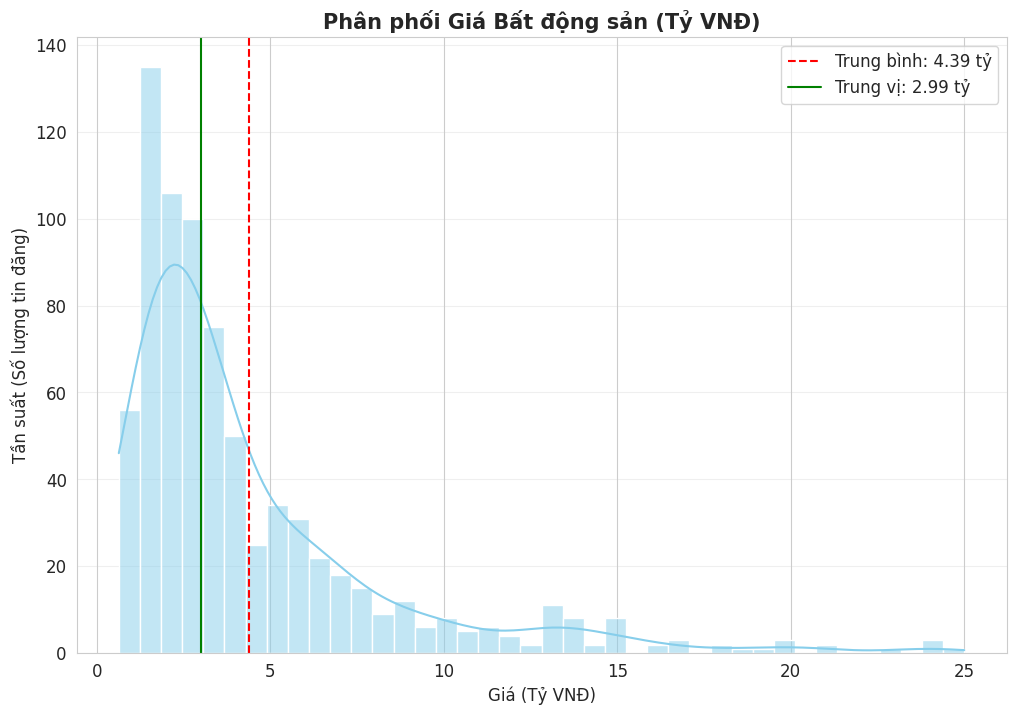

In [10]:
sns.histplot(df['gia(ty)'], bins=40, kde=True, color='skyblue', edgecolor='white')
mean_val = df['gia(ty)'].mean()
median_val = df['gia(ty)'].median()
plt.axvline(mean_val, color='red', linestyle='--', label=f'Trung bình: {mean_val:.2f} tỷ')
plt.axvline(median_val, color='green', linestyle='-', label=f'Trung vị: {median_val:.2f} tỷ')
plt.title('Phân phối Giá Bất động sản (Tỷ VNĐ)', fontsize=15, fontweight='bold')
plt.xlabel('Giá (Tỷ VNĐ)', fontsize=12)
plt.ylabel('Tần suất (Số lượng tin đăng)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Biểu đồ này cho thấy một thị trường bất động sản có độ lệch phải (right-skewed) rất mạnh.

Khoảng cách giữa đường Trung vị (2.99 tỷ - màu xanh) và Trung bình (4.39 tỷ - màu đỏ) là bằng chứng rõ ràng nhất cho thấy sự phân hóa mạnh. Đại đa số (hơn 50%) các bất động sản trên thị trường có giá dưới 3 tỷ.

Mức giá trung bình cao hơn đáng kể so với trung vị chứng tỏ tồn tại một nhóm nhỏ các bất động sản "siêu giá trị" (các điểm dữ liệu kéo dài về bên phải từ 10-25 tỷ). Nhóm này dù ít về số lượng nhưng tạo ra áp lực làm tăng giá trung bình toàn thị trường.

Nên kiểm tra xem nhóm "siêu giá trị" này là do diện tích lớn, vị trí đắc địa, hay là lỗi nhập liệu.

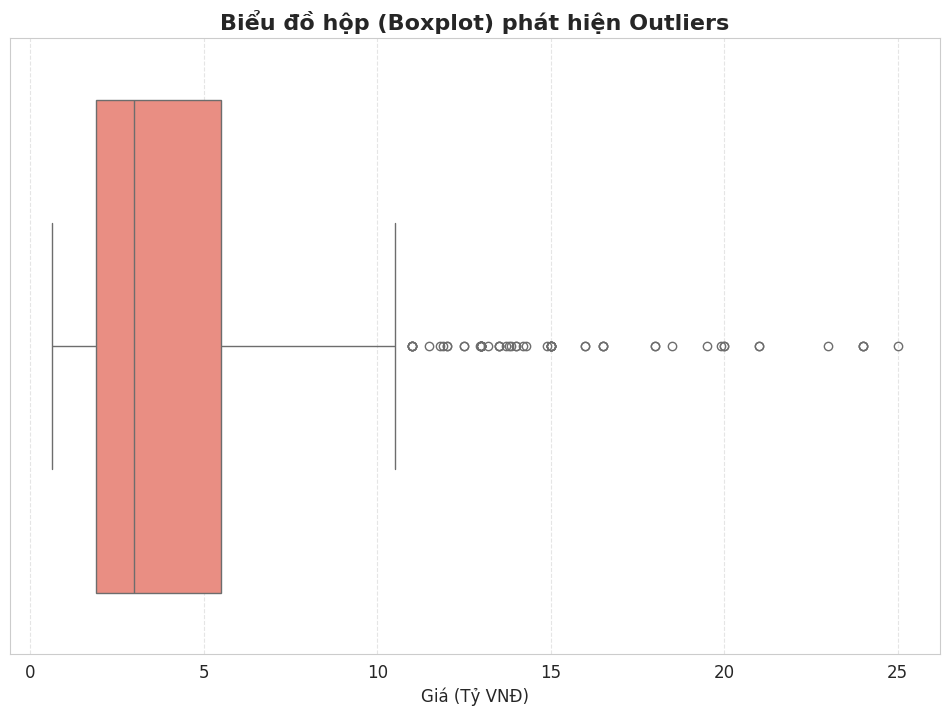

In [11]:
sns.boxplot(x=df['gia(ty)'], color='salmon')
plt.title('Biểu đồ hộp (Boxplot) phát hiện Outliers', fontsize=16, fontweight='bold')
plt.xlabel('Giá (Tỷ VNĐ)')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Biểu đồ giúp xác định "ranh giới" của thị trường phổ thông:

"Đuôi dài" (Long Tail) của dữ liệu: có một lượng rất lớn các điểm ngoại lai nằm từ ngưỡng 10 tỷ trở lên, kéo dài đến tận 25 tỷ.

Thị trường là thị trường lệch phải. Đại đa số giao dịch (phần hộp màu hồng) tập trung dưới 5 tỷ. Mọi bất động sản trên 10 tỷ được coi là "hàng hiếm" hoặc "phân khúc cao cấp" có tính chất hoàn toàn khác biệt so với thị trường chung.

Xử lý dữ liệu (Data Cleaning):

Nên cân nhắc áp dụng Log Transformation hoặc loại bỏ các tin đăng có giá trị vượt quá ngưỡng 99% (percentile) để giúp mô hình tập trung vào xu hướng chung của đại đa số người dùng.

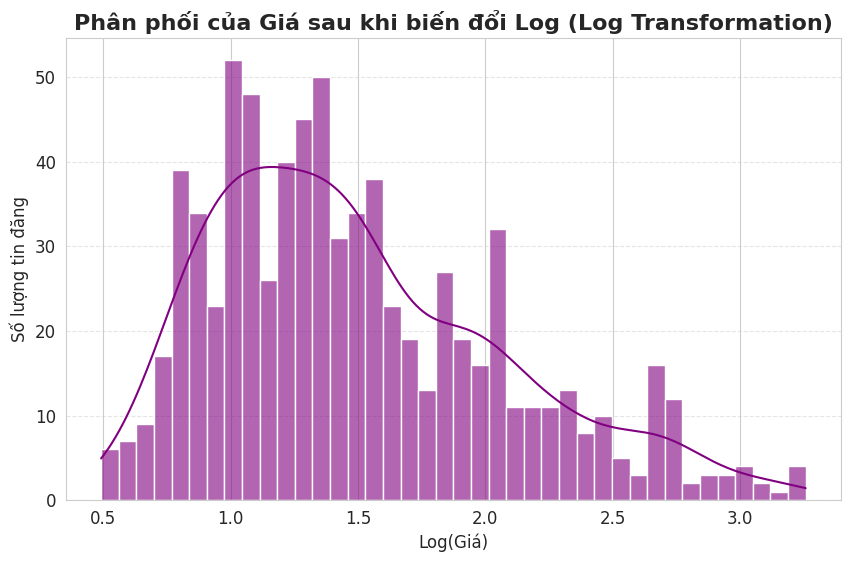

In [12]:
df['log_gia'] = np.log1p(df['gia(ty)'])
plt.figure(figsize=(10, 6))
sns.histplot(df['log_gia'], bins=40, kde=True, color='purple', edgecolor='white', alpha=0.6)
plt.title('Phân phối của Giá sau khi biến đổi Log (Log Transformation)', fontsize=16, fontweight='bold')
plt.xlabel('Log(Giá)', fontsize=12)
plt.ylabel('Số lượng tin đăng')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Bước biến đổi Log (Log Transformation) giúp đưa dữ liệu về dạng chuẩn:

Biểu đồ này cho thấy phân phối đã "bớt lệch" hơn rất nhiều so với biểu đồ giá gốc (lệch phải). Mặc dù nó chưa hoàn toàn là hình chuông (Normal Distribution) hoàn hảo, nhưng nó đã kéo các giá trị "siêu cao" (outliers) về gần hơn với đám đông.

Trong mô hình học máy (như Linear Regression), các thuật toán này "yêu" dữ liệu hình chuông hơn là dữ liệu lệch. Việc biến đổi này giúp mô hình không bị "ám ảnh" bởi những căn nhà giá 25 tỷ mà vẫn học được quy luật của những căn nhà 2-3 tỷ.

 Đường cong KDE vẫn còn hơi gồ ghề ở phía đuôi bên phải. Điều này cho thấy sau khi log, vẫn còn một vài giá trị ngoại lai rất lớn. Bạn có thể cân nhắc việc loại bỏ hoặc xử lý riêng các tin đăng nằm ở phân vị 99% trước khi train mô hình.

# Nhóm 2: Các đặc trưng vật lý và Giá trị đơn giá (Biến số)

1. Phân tích biến dien_tich(m2)

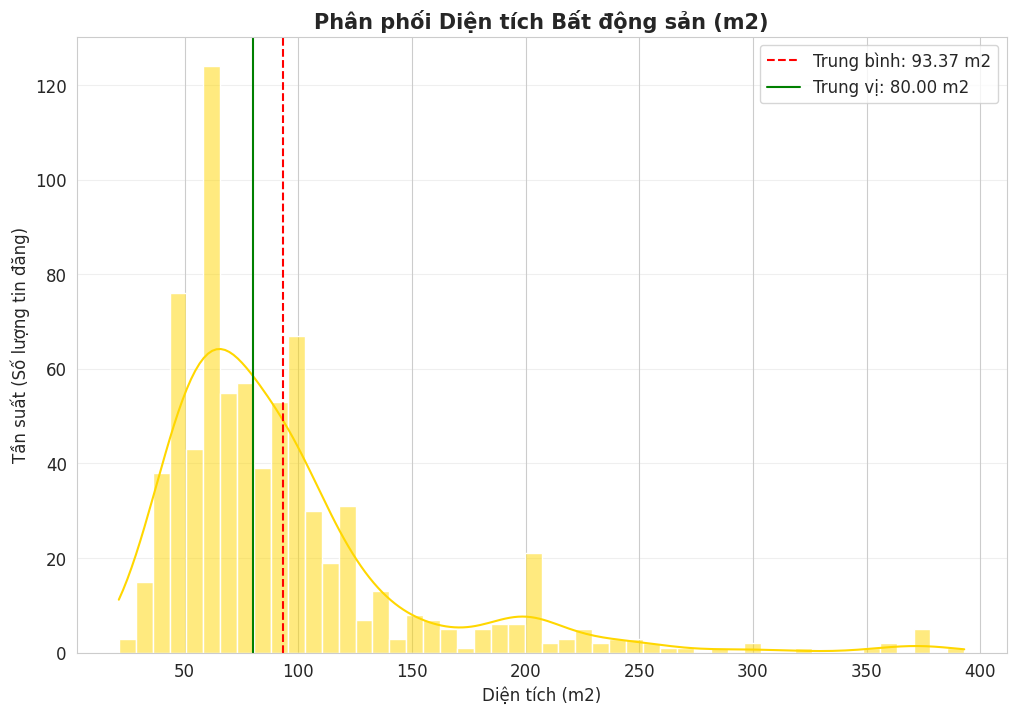

In [13]:
sns.histplot(df['dien_tich(m2)'], bins=50, kde=True, color='gold', edgecolor='white')
mean_area = df['dien_tich(m2)'].mean()
median_area = df['dien_tich(m2)'].median()
plt.axvline(mean_area, color='red', linestyle='--', label=f'Trung bình: {mean_area:.2f} m2')
plt.axvline(median_area, color='green', linestyle='-', label=f'Trung vị: {median_area:.2f} m2')
plt.title('Phân phối Diện tích Bất động sản (m2)', fontsize=15, fontweight='bold')
plt.xlabel('Diện tích (m2)', fontsize=12)
plt.ylabel('Tần suất (Số lượng tin đăng)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Hình thái phân phối (Distribution Shape)

Độ lệch phải (Right-Skewed): Biểu đồ cho thấy phân phối không đối xứng mà bị kéo dài sang phải. Điều này là hoàn toàn bình thường trong dữ liệu bất động sản. Đại đa số nguồn cung tập trung vào các bất động sản diện tích nhỏ và trung bình (từ 50m² - 120m²), trong khi số lượng biệt thự hoặc quỹ đất lớn (trên 200m² - 300m²) chiếm tỷ trọng rất thấp.

Độ chênh lệch giữa Trung bình và Trung vị:

Trung vị (Median = 80 m²) thấp hơn Trung bình (Mean = 93.37 m²). Mức trung bình bị "kéo" lên cao bởi những sản phẩm có diện tích rất lớn (các "đầu kéo" ở đuôi phải). Đối với các bài toán dự báo giá, Trung vị (80 m²) mới là con số phản ánh đúng "thực trạng" của phần lớn bất động sản đang giao dịch trên thị trường.

Phát hiện các nhóm dữ liệu đặc thù (Data Clustering)

Đỉnh cao nhất (Mode): Có một "đỉnh" rất rõ nét ở khoảng 60-70 m². Đây chính là diện tích tiêu chuẩn của các căn hộ chung cư hoặc nhà phố phân lô tại Bình Định.

"Bướu" thứ hai (Bimodal Tendency): Nếu quan sát kỹ đường cong KDE màu vàng, bạn sẽ thấy một "bướu" nhỏ ở khoảng 200 m². Đây là sự phân tách phân khúc thị trường. Nhóm 60-100 m² là phân khúc phổ thông (nhà ở/căn hộ), còn nhóm xung quanh 200 m² có thể là phân khúc nhà vườn hoặc đất nền biệt thự. Khi xây dựng mô hình dự báo giá, nếu bạn đưa biến "diện tích" này vào mà không phân loại, mô hình sẽ rất khó hội tụ vì hai nhóm này có cách định giá trên m² hoàn toàn khác nhau.



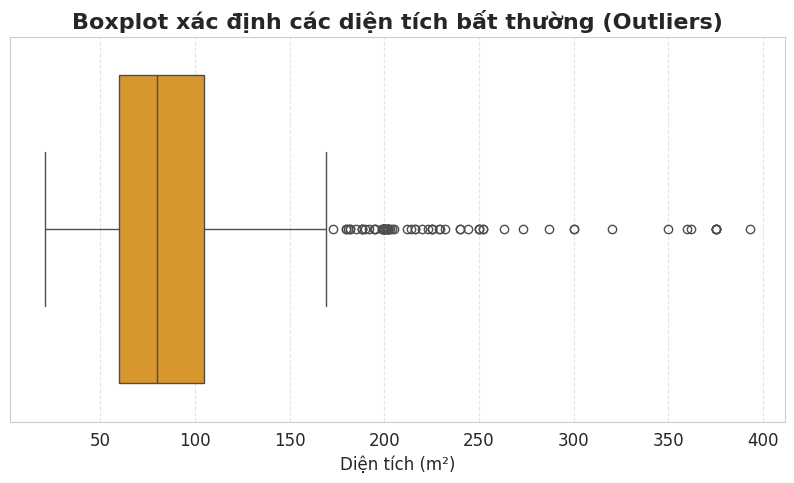

In [14]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['dien_tich(m2)'], color='#f39c12')
plt.title('Boxplot xác định các diện tích bất thường (Outliers)', fontsize=16, fontweight='bold')
plt.xlabel('Diện tích (m²)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Cấu trúc (Phần "hộp" và "râu"):

Phân khúc chủ đạo: Phần hộp màu cam đại diện cho 50% dữ liệu trung tâm (từ khoảng 60m² đến hơn 100m²). Đây là "ADN" của thị trường bất động sản tại khu vực này: nhà phố, căn hộ chung cư hoặc đất nền nhà ống.

Độ phân tán (IQR): Độ rộng của hộp cho thấy sự đồng nhất tương đối cao trong nhóm sản phẩm phổ thông. Dữ liệu tập trung chặt chẽ, chứng tỏ đây là phân khúc có tính thanh khoản cao nhất.

"Bão" Outliers có rất nhiều các chấm tròn phía bên phải kéo dài từ ngưỡng ~170m² cho đến tận gần 400m². Trong bất động sản, các điểm này đại diện cho:

Biệt thự đơn lập/song lập: Những sản phẩm cao cấp có diện tích đất lớn.

Đất nền dự án/Đất nông nghiệp gộp lô: Các mảnh đất có mục đích sử dụng khác biệt.

Dữ liệu nhiễu (Dữ liệu lỗi): Có khả năng một vài tin đăng nhập sai đơn vị (ví dụ: nhập diện tích tổng của cả dự án thay vì diện tích căn hộ).

Tóm lại, biểu đồ Boxplot đã phơi bày sự phân hóa mạnh mẽ trong quy mô sản phẩm. Trong khi phần lớn thị trường hoạt động ổn định ở quy mô dưới 100m², sự xuất hiện dày đặc của các giá trị ngoại lai (outliers) phía trên 170m² cho thấy sự tồn tại của các phân khúc 'ngách' như biệt thự hoặc đất nền diện tích lớn. Điều này cảnh báo rằng: Diện tích không phải là biến số tăng trưởng tuyến tính. Một mô hình dự báo chính xác cần phải xử lý các outliers này một cách riêng biệt (thông qua kỹ thuật log-transformation hoặc phân loại nhóm diện tích) thay vì gộp chung vào tập dữ liệu huấn luyện.

2. Phân tích biến đơn giá trieu/m2

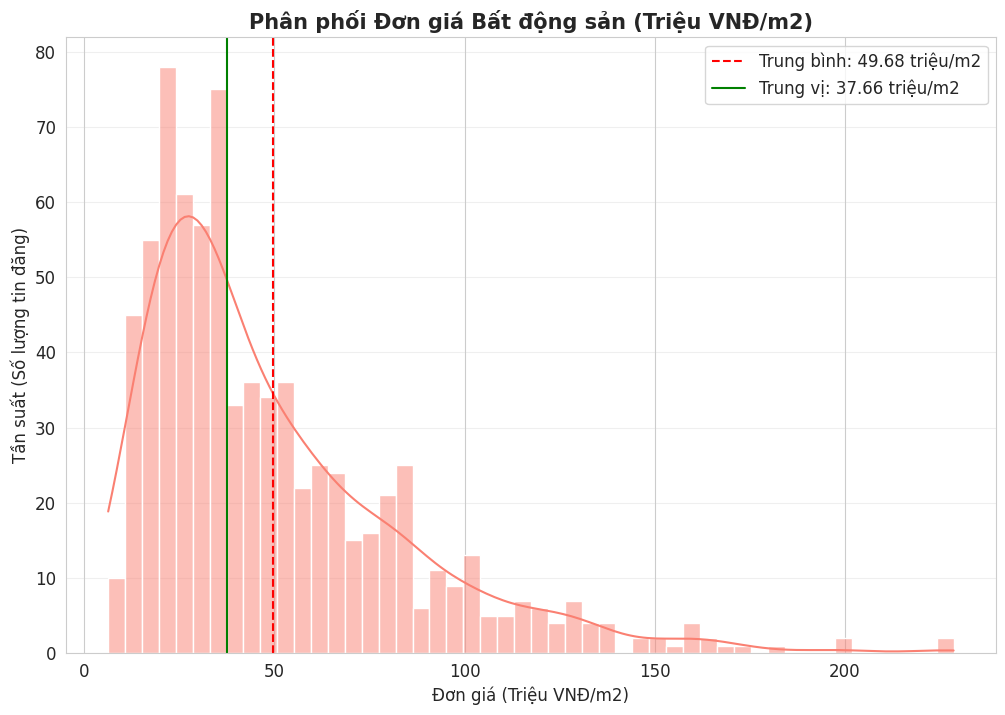

In [15]:
sns.histplot(df['trieu/m2'], bins=50, kde=True, color='salmon', edgecolor='white')
mean_price_m2 = df['trieu/m2'].mean()
median_price_m2 = df['trieu/m2'].median()
plt.axvline(mean_price_m2, color='red', linestyle='--', label=f'Trung bình: {mean_price_m2:.2f} triệu/m2')
plt.axvline(median_price_m2, color='green', linestyle='-', label=f'Trung vị: {median_price_m2:.2f} triệu/m2')
plt.title('Phân phối Đơn giá Bất động sản (Triệu VNĐ/m2)', fontsize=15, fontweight='bold')
plt.xlabel('Đơn giá (Triệu VNĐ/m2)', fontsize=12)
plt.ylabel('Tần suất (Số lượng tin đăng)', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Hình thái Phân phối (Distribution Analysis)

Độ lệch phải (Right-Skewed): Tương tự như biểu đồ giá tổng, đơn giá (triệu/m2) cũng cho thấy sự lệch phải rõ rệt. Đa số các bất động sản trên thị trường có đơn giá tập trung ở mức thấp đến trung bình, trong khi phía bên phải có một "đuôi dài" kéo dài đến trên 200 triệu/m2.

Khoảng cách giữa Trung bình (Mean: 49.68) và Trung vị (Median: 37.66):

Khoảng cách này (gần 12 triệu/m2) là rất lớn. Điều này khẳng định rằng giá trị trung bình đang bị méo mó bởi các bất động sản siêu cao cấp hoặc các vị trí cực kỳ đắc địa.

Sự phân hóa thị trường (Market Segmentation)
Vùng tập trung (The Sweet Spot): Có thể thấy rõ một "đỉnh" lớn nằm trong khoảng từ 20 đến 40 triệu/m2. Đây chính là phân khúc chủ lực, nơi giao dịch diễn ra sôi động nhất.

Đuôi phân phối (The Long Tail): Các giá trị nằm từ 100 đến 200+ triệu/m2 chính là "phân khúc kim cương". Đây thường là những vị trí mặt tiền các trục đường huyết mạch (ví dụ: Xuân Diệu, An Dương Vương) hoặc các dự án cao cấp ven biển.

Sự phân hóa này cho thấy thị trường có tính phân tầng cao độ. Nếu bạn dùng một mô hình hồi quy duy nhất, nó sẽ khó lòng dự báo chính xác cho cả vùng 30 triệu/m2 và vùng 150 triệu/m2.



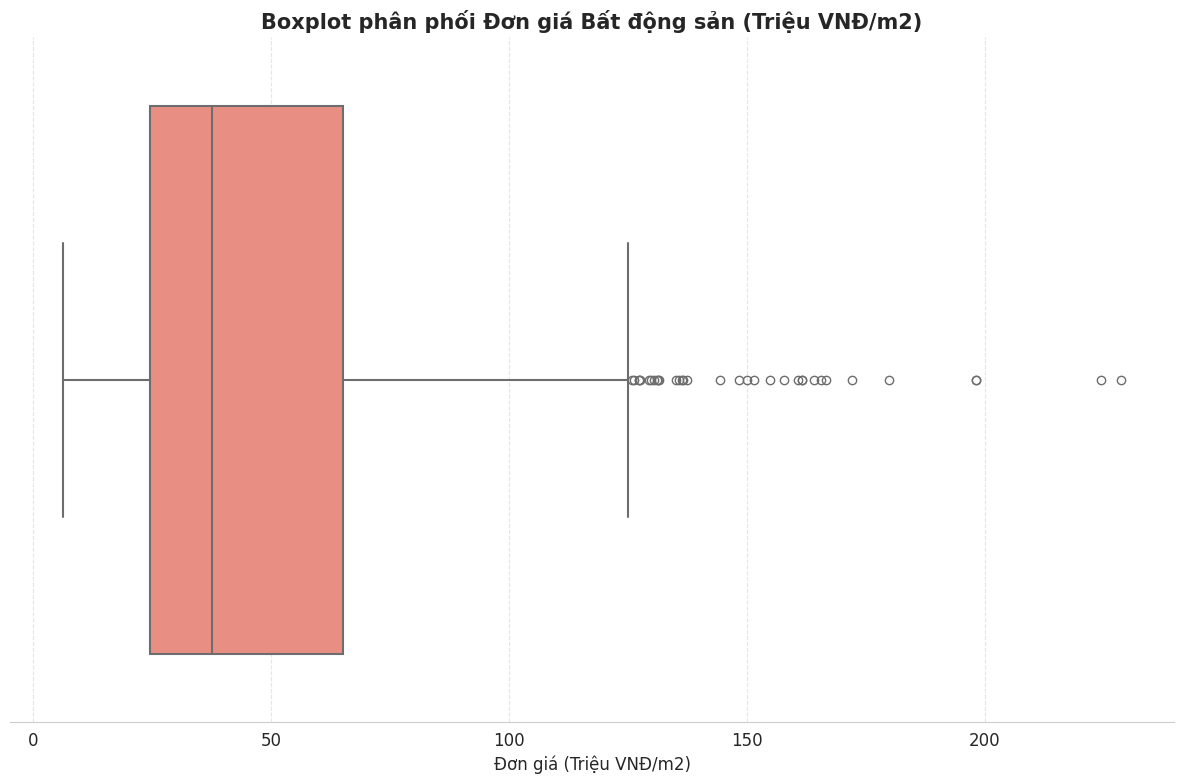

In [16]:
sns.boxplot(x=df['trieu/m2'], color='salmon', fliersize=6, linewidth=1.5)
plt.title('Boxplot phân phối Đơn giá Bất động sản (Triệu VNĐ/m2)', fontsize=15, fontweight='bold')
plt.xlabel('Đơn giá (Triệu VNĐ/m2)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
sns.despine(left=True)
plt.tight_layout()
plt.show()

Cấu trúc phân phối:

Phân khúc thị trường chủ đạo (Phần hộp màu hồng): Khoảng cách từ vạch chia (trung vị) về phía bên trái cho thấy phần lớn các bất động sản phổ thông có đơn giá tập trung ở mức thấp, khả năng cao nằm trong khoảng từ 20 đến 60 triệu/m2. Đây là phân khúc có tính thanh khoản cao, phù hợp với nhu cầu nhà ở thực.

Độ phân tán (Độ rộng của hộp): Chiều dài của hộp cho thấy sự biến động giá (IQR) của phân khúc phổ thông này khá đáng kể. Điều này phản ánh rằng ngay trong phân khúc bình dân/trung cấp, đơn giá đã có sự chênh lệch lớn tùy thuộc vào vị trí (hẻm, mặt tiền) hoặc tình trạng pháp lý.

Sự hiện diện của "Đuôi dài" (Outliers - Các chấm tròn)
Đây là điểm đắt giá nhất của biểu đồ:

Các điểm ngoại lai (Outliers): Bạn có một loạt các chấm tròn nằm trải dài từ ngưỡng 130 triệu/m2 đến tận 230 triệu/m2. Những điểm này không nên bị coi là "dữ liệu rác". Trong bất động sản, đây là các tài sản chiến lược. Chúng đại diện cho:

Vị trí đắc địa: Các bất động sản nằm trên các trục đường thương mại huyết mạch hoặc mặt tiền biển (nếu ở khu vực du lịch).

Tiềm năng thương mại: Những lô đất có khả năng kinh doanh, dịch vụ cao.

Phân khúc hạng sang: Những dự án căn hộ cao cấp hoặc nhà phố được quy hoạch đồng bộ.



3. Phân tích Kích thước hình học (ngang, doc)

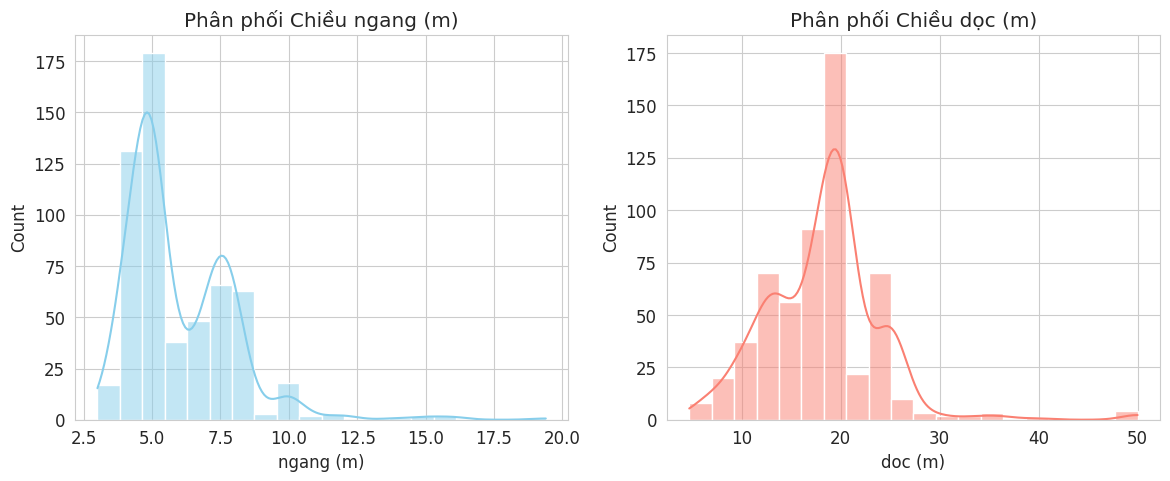

In [17]:
# Lọc dữ liệu bỏ qua các giá trị 0
temp_df = df[(df['ngang (m)'] > 0) & (df['doc (m)'] > 0)].copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(temp_df['ngang (m)'], bins=20, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Phân phối Chiều ngang (m)')
sns.histplot(temp_df['doc (m)'], bins=20, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Phân phối Chiều dọc (m)')
plt.show()



Chiều ngang (ngang m) - "Bản sắc mặt tiền"

Đa đỉnh (Multimodal): Biểu đồ không có một đỉnh duy nhất mà xuất hiện ít nhất hai đỉnh rõ rệt (đỉnh lớn ở khoảng 5m và đỉnh nhỏ ở khoảng 7-8m).nĐiều này phản ánh sự phân hóa trong quy hoạch địa phương:

Đỉnh 5m: Đây là chuẩn mực của nhà phố/đất nền phân lô phổ thông.

Đỉnh 7-8m: Phản ánh các khu vực quy hoạch biệt thự hoặc nhà phố diện tích lớn hơn, giá trị cao hơn.

Chiều ngang (mặt tiền) là biến số định giá trực tiếp. Việc dữ liệu tập trung nhiều ở đỉnh 5m cho thấy đây là phân khúc "hàng hóa" dễ thanh khoản nhất thị trường.

Chiều dọc (doc m) - "Bản sắc chiều sâu"

Phân phối tập trung: Khác với chiều ngang, chiều dọc có một đỉnh rất rõ rệt ở khoảng 18-20m. Quy hoạch đất nền tại khu vực này có tính đồng nhất cao về chiều sâu. Điều này cho thấy sự quản lý quy hoạch khá chặt chẽ, tạo ra các lô đất có hình dạng chuẩn (không quá méo hay quá ngắn).

Độ lệch nhẹ: Có một "đuôi" nhỏ kéo dài về phía 30-50m, đây chính là các lô đất có chiều sâu bất thường (đất dài). Những lô đất có chiều sâu trên 30m mà chiều ngang chỉ 4-5m thường là những lô đất có tỷ lệ "nhà ống" cực đoan, thường khó bố trí công năng và có thể có mức giá trên m2 thấp hơn so với các lô vuông vắn.



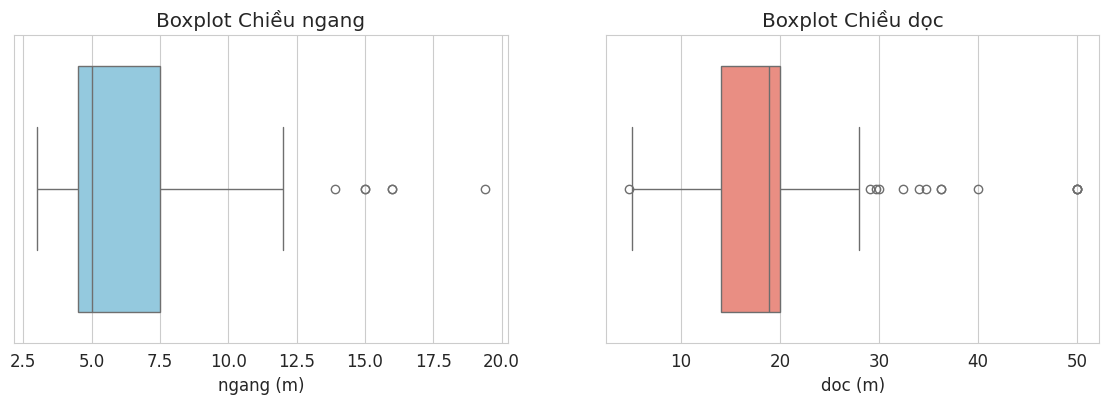

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=temp_df['ngang (m)'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot Chiều ngang')
sns.boxplot(x=temp_df['doc (m)'], color='salmon', ax=axes[1])
axes[1].set_title('Boxplot Chiều dọc')
plt.show()

Cấu trúc phân phối

Phân khúc thị trường chủ đạo (Phần hộp màu xanh):

Dữ liệu tập trung rất chặt chẽ từ khoảng 4.5m đến 7.5m. Đây là bằng chứng xác thực nhất cho thấy thị trường bất động sản này bị thống trị bởi nhà phố phân lô và đất nền dự án.

Độ rộng của hộp (IQR) khá hẹp, cho thấy sự đồng nhất cao về chiều ngang mặt tiền trong phân khúc đại trà, giúp việc quy hoạch và thiết kế kiến trúc tại khu vực này có tính đồng bộ lớn.

Trung vị (Vạch kẻ trong hộp):

Trung vị nằm ở mức khoảng 5m. Đây là "con số vàng" của bất động sản nhà ở tại Việt Nam, vì nó vừa đủ để thiết kế các không gian chức năng cơ bản, đồng thời tối ưu hóa được số lượng lô đất trên mỗi mét dài mặt đường.

Các giá trị ngoại lai:

Có một nhóm các chấm tròn nằm tách biệt ở phía bên phải (từ 13m đến 20m). Đây không phải là dữ liệu lỗi, mà là các "tài sản đặc thù".

Những bất động sản có mặt tiền > 13m thường là:

Đất lô góc (corner lot): Có hai mặt tiền nên chiều ngang thực tế lớn.

Biệt thự hoặc trụ sở kinh doanh: Những lô đất lớn được gộp thửa (gộp từ 2-3 lô đất nền tiêu chuẩn).

Đất thương mại dịch vụ: Những vị trí đắc địa cần mặt tiền rộng để kinh doanh.

Ý nghĩa đối với việc dự báo giá
Việc xuất hiện các outliers này nhắc nhở chúng ta một điều quan trọng trước khi huấn luyện mô hình (Model Training): Nếu sử dụng biến ngang (m) làm đầu vào mà không xử lý các outliers này, mô hình sẽ gặp khó khăn. Một căn nhà mặt tiền 5m và một căn nhà mặt tiền 20m có giá trị phi tuyến tính.


 Nhóm 2 đã thực hiện thành công việc "bóc tách" đặc điểm vật lý của bất động sản. Thị trường này hoạt động dựa trên hai lớp dữ liệu: lớp cơ bản (phân khúc 5x20m, diện tích 80 $m^2$) chiếm số lượng lớn và lớp cao cấp (các outliers) chiếm giá trị lớn. Đây là nền tảng cực kỳ vững chắc để bạn xây dựng các biến đặc trưng (Feature Engineering) cho mô hình dự báo giá trong các bước tiếp theo.

# Nhóm 3: Các đặc trưng xây dựng

In [19]:
# Tạo tập dữ liệu tạm thời house_df chỉ chứa các bất động sản đã có công trình thực tế
house_df = df[(df['so_tang'] > 0) &
              (df['so_phong_ngu'] > 0) &
              (df['so_wc'] > 0)].copy()

print(f"Dữ liệu gốc: {len(df)} tin | Dữ liệu nhà ở (đã lọc): {len(house_df)} tin")

Dữ liệu gốc: 767 tin | Dữ liệu nhà ở (đã lọc): 558 tin


1. Phân tích biến so_tang (Số tầng)

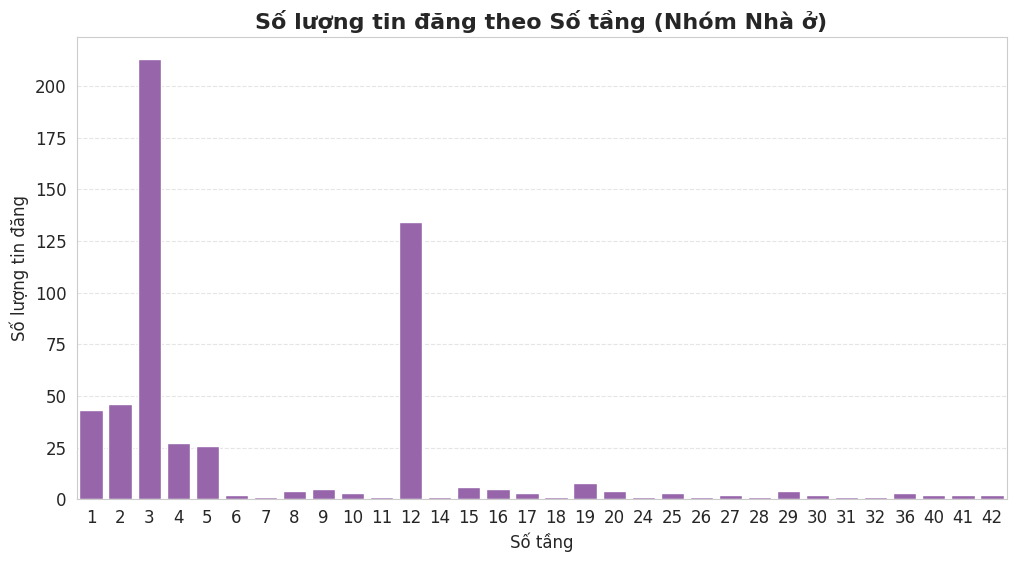

In [20]:
plt.figure(figsize=(12, 6))
sns.countplot(x='so_tang', data=house_df, color='#9b59b6', edgecolor='white')
plt.title('Số lượng tin đăng theo Số tầng (Nhóm Nhà ở)', fontsize=16, fontweight='bold')
plt.xlabel('Số tầng', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Nhóm nhà thấp tầng (1-3 tầng): Đây rõ ràng là phân khúc chủ đạo. Đặc biệt, cột 3 tầng nổi bật nhất, phản ánh xu hướng thiết kế nhà phố tiêu chuẩn của cư dân tại khu vực này.

Nhóm dự án cao tầng (12 tầng): Cột 12 tầng vẫn hiển thị rất rõ. Đây là một điểm nhấn thú vị, cho thấy sự hiện diện dày đặc của các tòa nhà chung cư hoặc văn phòng tầm trung, chiếm vị thế quan trọng trong cấu trúc đô thị.

Các cột lẻ tẻ ở mức cao (15, 19, 25, 36, 42 tầng) giờ đây trở nên rõ nét hơn, giúp người xem thấy được sự tồn tại của các tòa nhà biểu tượng xen kẽ trong một đô thị chủ yếu là nhà phố thấp tầng.

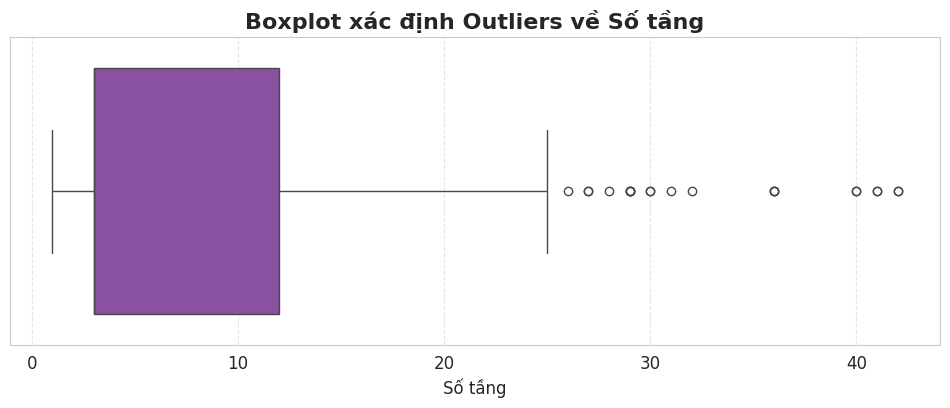

In [21]:
plt.figure(figsize=(12, 4))
sns.boxplot(x='so_tang', data=house_df, color='#8e44ad')
plt.title('Boxplot xác định Outliers về Số tầng', fontsize=16, fontweight='bold')
plt.xlabel('Số tầng', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Cấu trúc dữ liệu: Phần hộp màu tím (interquartile range) phản ánh rằng 50% dữ liệu trung tâm tập trung ở dải số tầng khá thấp, nhấn mạnh một lần nữa tính chất "thấp tầng" của đại đa số bất động sản.

Nhận diện "Tòa nhà biểu tượng": Các điểm ngoại lai (outliers) nằm rải rác từ mức 25 đến trên 40 tầng không phải là dữ liệu lỗi, mà là các dự án bất động sản cao cấp, mang tính biểu tượng của khu vực như TMS Quy Nhơn hoặc The Sailing.

Biểu đồ này chỉ ra sự phân hóa mạnh mẽ giữa bất động sản nhà ở truyền thống và bất động sản cao tầng/căn hộ nghỉ dưỡng. Đối với mô hình dự báo giá, những dự án cao tầng (outliers) này cần được xử lý riêng biệt hoặc gắn nhãn (feature engineering) vì cơ chế định giá của chúng hoàn toàn khác biệt so với các căn nhà phố thông thường.

2. Phân tích biến so_phong_ngu (Số phòng ngủ)

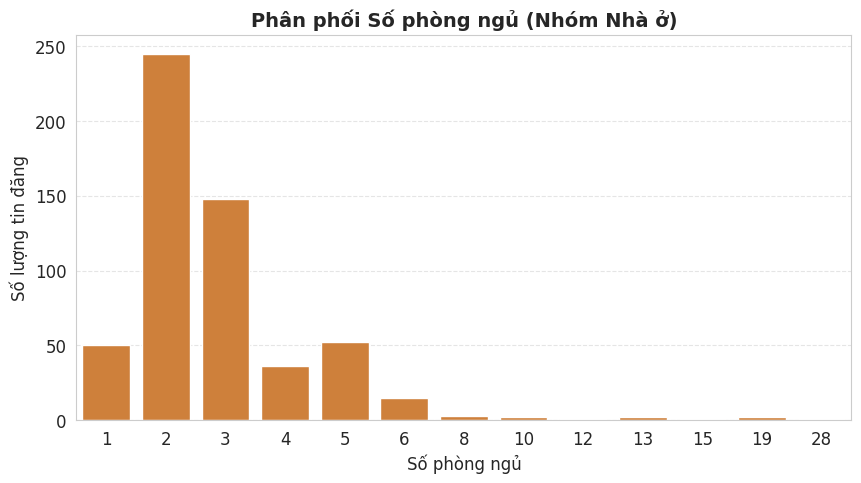

In [22]:
plt.figure(figsize=(10, 5))
sns.countplot(x='so_phong_ngu', data=house_df, color='#e67e22', edgecolor='white')
plt.title('Phân phối Số phòng ngủ (Nhóm Nhà ở)', fontsize=14, fontweight='bold')
plt.xlabel('Số phòng ngủ', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Đặc điểm "Nhà ở gia đình": Biểu đồ cho thấy một sự tập trung rất cao tại các phân khúc 2 phòng ngủ (đỉnh cao nhất) và 3 phòng ngủ. Điều này phản ánh cực kỳ sát thực tế nhu cầu nhà ở tại Quy Nhơn, nơi các căn hộ hoặc nhà phố 2-3 phòng ngủ là cấu hình tiêu chuẩn cho một gia đình hạt nhân.

Sự sụt giảm tự nhiên: Số lượng tin đăng giảm dần khi số phòng ngủ tăng lên từ 4 đến 6, thể hiện quy luật cung - cầu: bất động sản càng lớn (nhiều phòng) thì càng hiếm và tệp khách hàng càng thu hẹp.

"Đuôi dài" (Long tail) của dữ liệu: Các cột ở mức 10, 13, 19 phòng ngủ cho thấy sự xuất hiện của các bất động sản kinh doanh quy mô vừa, không phải là nhà ở thuần túy.

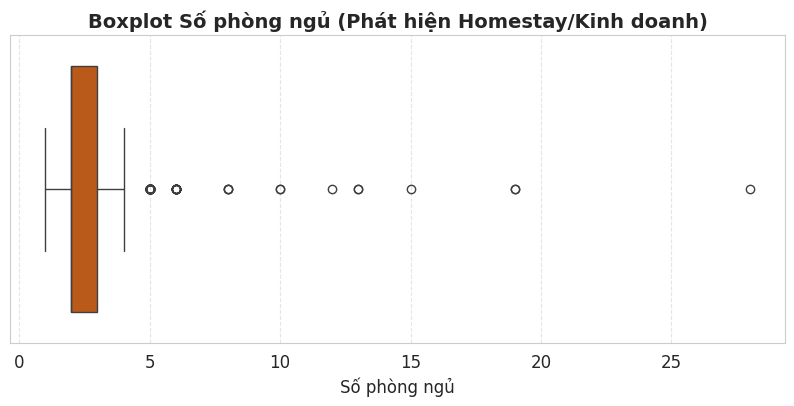

In [23]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='so_phong_ngu', data=house_df, color='#d35400')
plt.title('Boxplot Số phòng ngủ (Phát hiện Homestay/Kinh doanh)', fontsize=14, fontweight='bold')
plt.xlabel('Số phòng ngủ', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Bức tranh về "Bình thường mới": Phần hộp (Box) của biểu đồ rất hẹp, tập trung chủ yếu trong khoảng 2-3 phòng ngủ. Đây là vùng "định giá chuẩn" mà mô hình dự báo sẽ hoạt động chính xác nhất.

Vạch mặt "Kẻ ngoại đạo" (Outliers):

Các điểm chấm tròn (outliers) bên phải biểu đồ, đặc biệt là điểm đơn lẻ tận cùng ở 28 phòng ngủ, chính là "chìa khóa" để giải thích sự biến động giá.

Những tài sản này không thể định giá theo công thức thông thường (ví dụ: nhân diện tích x đơn giá/m2) vì giá trị của chúng nằm ở khả năng tạo dòng tiền (doanh thu từ Homestay/khách sạn). Việc tách nhóm này ra khỏi dữ liệu huấn luyện (training data) sẽ giúp giảm đáng kể sai số (RMSE) cho mô hình dự báo bất động sản dân dụng.

3. Phân tích biến so_wc (Số nhà vệ sinh)

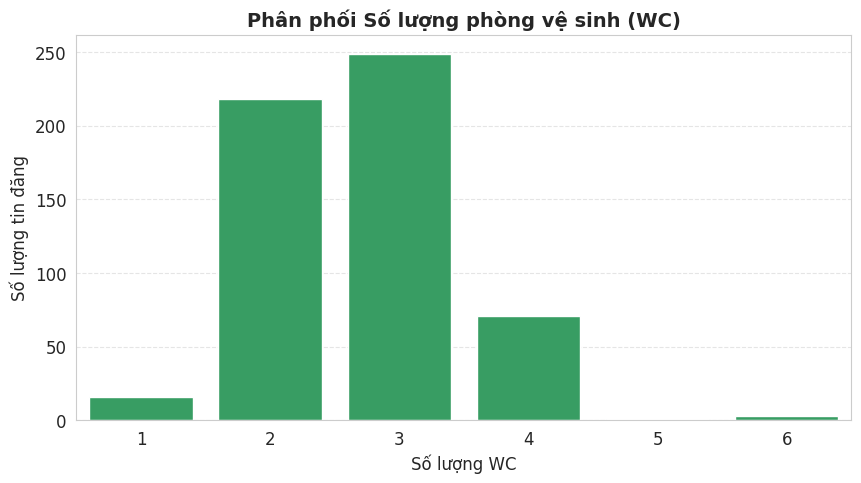

In [24]:
plt.figure(figsize=(10, 5))
sns.countplot(x='so_wc', data=house_df, color='#27ae60', edgecolor='white')
plt.title('Phân phối Số lượng phòng vệ sinh (WC)', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng WC', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

Đỉnh tiện nghi (Tiêu chuẩn): Biểu đồ cho thấy thị trường tập trung mạnh mẽ ở mức 2 và 3 WC. Đây là "tiêu chuẩn vàng" cho các loại hình nhà ở gia đình và căn hộ, đảm bảo công năng sử dụng cơ bản cho các hộ gia đình từ 3-5 thành viên.

Tính đồng nhất: Việc giảm mạnh số lượng tin đăng ở mức 4-6 WC cho thấy các bất động sản "siêu tiện nghi" chỉ chiếm một tỷ trọng nhỏ, phù hợp với quy luật phân bổ tự nhiên của thị trường.

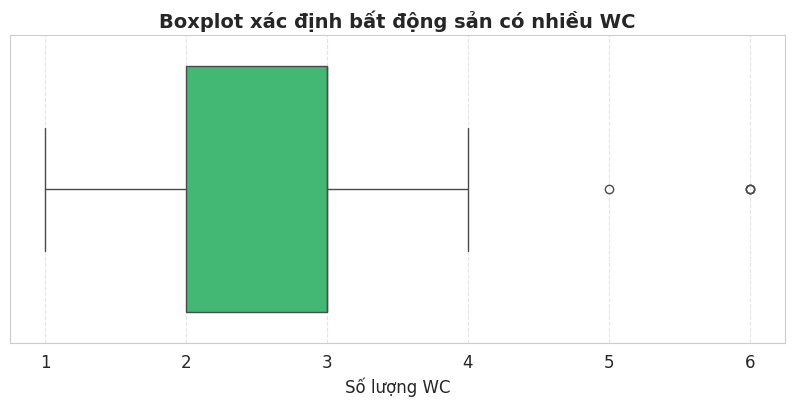

In [25]:
plt.figure(figsize=(10, 4))
sns.boxplot(x='so_wc', data=house_df, color='#2ecc71')
plt.title('Boxplot xác định bất động sản có nhiều WC', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng WC', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

Hộp (box) giờ đây bao trọn phân khúc từ 2 đến 3 WC, mô tả chính xác 50% dữ liệu trung tâm của thị trường.

Các điểm chấm tròn ở mức 5 và 6 WC trở nên nổi bật hơn. Đây chính là các bất động sản cao cấp, biệt thự, hoặc nhà phố lớn có nhiều tầng/nhiều phòng ngủ.

Điều này cho thấy số lượng WC tăng dần đều theo quy mô bất động sản. Không có trường hợp "quá bất thường" (ví dụ: một căn nhà nhỏ mà có tới 10 WC). Mối quan hệ giữa diện tích và số lượng WC là khá tuyến tính và hợp lý.

Giới hạn tối đa: Mức 6 WC đóng vai trò là "trần tiện nghi" cho các bất động sản cao cấp, biệt thự lớn.

# Nhóm 4: Các đặc điểm định tính (Biến phân loại)

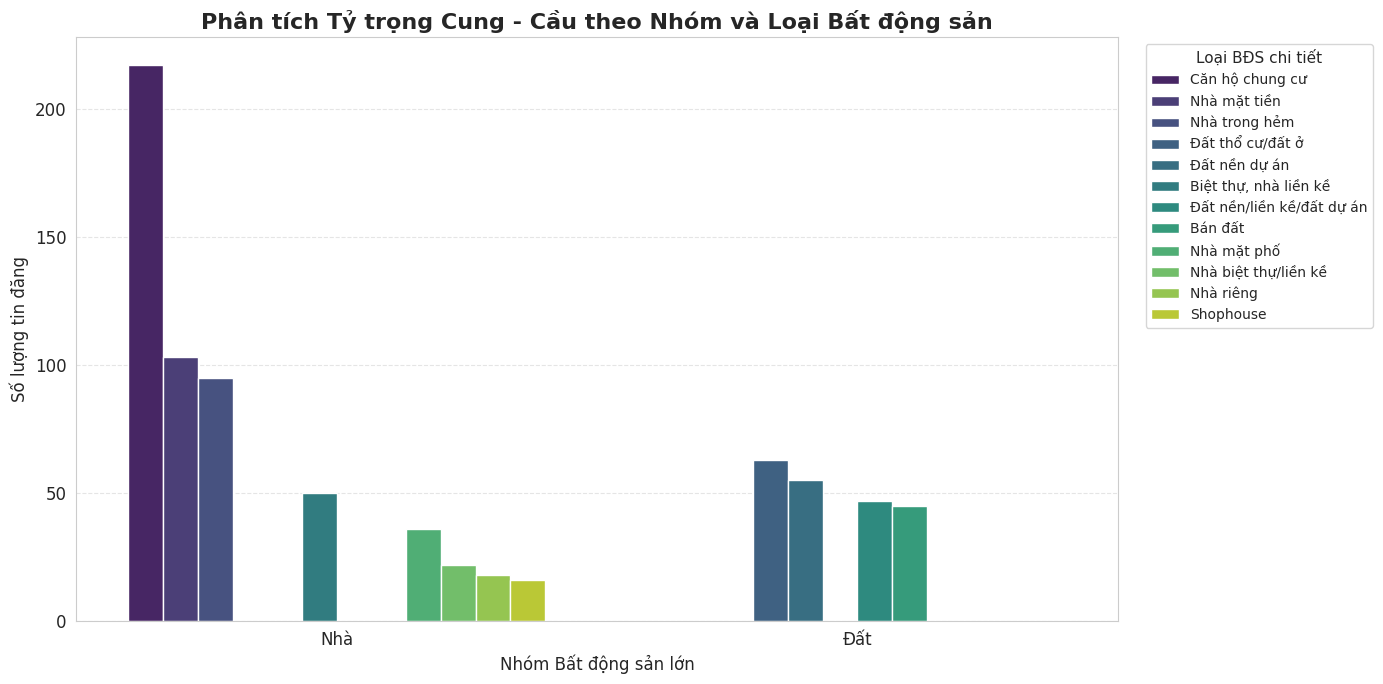

In [26]:
# 1. Tối ưu dữ liệu: Gom các loại hình ít phổ biến vào nhóm 'Khác' (nếu cần)
# Hoặc đơn giản là sắp xếp dữ liệu để biểu đồ đẹp hơn
df_plot = df.copy()
# Giả sử bạn muốn sắp xếp theo thứ tự số lượng tin đăng giảm dần
order_list = df_plot['loai_bds'].value_counts().index
# 2. Vẽ biểu đồ với thứ tự đã sắp xếp
plt.figure(figsize=(14, 7))
# Sử dụng 'hue_order' để các cột trong cùng nhóm 'Nhà' hoặc 'Đất' tự động sắp xếp theo độ cao
sns.countplot(x='nhom_bds_lon',
              hue='loai_bds',
              data=df_plot,
              palette='viridis',
              edgecolor='white',
              hue_order=order_list) # Sắp xếp màu sắc theo độ phổ biến
# 3. Tinh chỉnh giao diện
plt.title('Phân tích Tỷ trọng Cung - Cầu theo Nhóm và Loại Bất động sản', fontsize=16, fontweight='bold')
plt.xlabel('Nhóm Bất động sản lớn', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.legend(title='Loại BĐS chi tiết', title_fontsize='11', fontsize='10', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout() # Giúp nhãn không bị cắt mất
plt.show()

Phân khúc "Căn hộ chung cư" là trọng tâm của nhóm "Nhà"
Phát hiện quan trọng: Trong nhóm "Nhà", loại hình "Căn hộ chung cư" chiếm vị thế áp đảo tuyệt đối về số lượng tin đăng, bỏ xa các loại hình nhà phố hay biệt thự.

Ý nghĩa: Điều này cho thấy thị trường bạn đang phân tích có sự phát triển mạnh mẽ của loại hình nhà ở cao tầng/căn hộ. Đây là phân khúc có tính chất "hàng hóa" cao, đồng nhất về thiết kế và dễ dàng định giá theo diện tích, rất phù hợp để xây dựng mô hình dự báo giá.

Sự phân hóa rõ rệt của nhóm "Đất"
Phát hiện quan trọng: Nhóm "Đất" có sự phân bổ tương đối đồng đều giữa các loại hình như "Đất thổ cư", "Đất nền", và "Bán đất". Không có một loại hình nào chiếm vị thế độc tôn như "Căn hộ" bên nhóm "Nhà".

Ý nghĩa: Điều này khẳng định tính đa dạng của sản phẩm đất nền. Người mua đất tại đây có nhiều lựa chọn từ đất thổ cư (thường là nhà đất có sẵn) đến đất nền dự án (đất phân lô). Chính vì sự đa dạng này, khi định giá nhóm "Đất", bạn sẽ cần chú trọng nhiều hơn vào biến Vị trí (Location) và Pháp lý thay vì chỉ dựa vào các thông số công năng.

Sự khác biệt về tính chất giữa hai nhóm
Tính chuyên biệt: Biểu đồ cho thấy sự tách biệt hoàn toàn giữa hai thế giới:

Nhóm Nhà: Tập trung vào các sản phẩm đã hình thành, thiên về nhu cầu ở thực hoặc cho thuê (chung cư, nhà mặt phố, shophouse).

Nhóm Đất: Tập trung vào nhu cầu đầu tư tích sản.

Chiến lược dữ liệu: Việc trực quan hóa này củng cố luận điểm quan trọng nhất cho báo cáo của bạn: "Không thể dùng chung một mô hình định giá cho Nhà và Đất". Vì cấu trúc sản phẩm và đặc tính thị trường của hai nhóm này là hoàn toàn khác biệt.

"Thông qua biểu đồ tỷ trọng Cung - Cầu, ta thấy rõ thị trường bất động sản đang vận hành theo hai quỹ đạo riêng biệt: Nhóm Nhà dẫn dắt bởi phân khúc căn hộ quy mô lớn, và nhóm Đất vận hành theo đa dạng loại hình đầu tư. Việc tách biệt hai nhóm này trong quá trình xử lý dữ liệu và xây dựng mô hình dự báo là bước đi tất yếu để đạt được độ chính xác cao nhất."

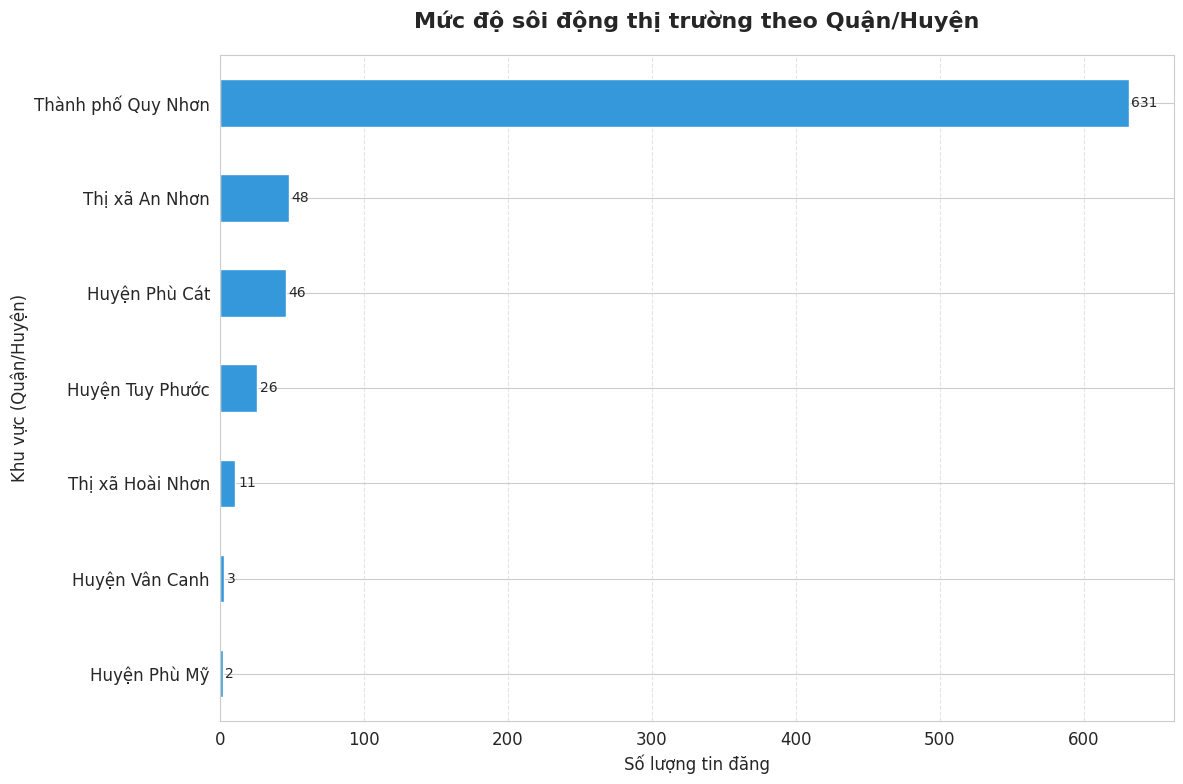

In [27]:
# 1. Tính toán số lượng tin đăng theo từng quận/huyện
# Sắp xếp để biểu đồ có thứ tự từ cao xuống thấp (giúp dễ đọc nhất)
district_counts = df['quan_huyen'].value_counts().sort_values(ascending=True)

# 2. Cấu hình biểu đồ
plt.figure(figsize=(12, 8))

# 3. Vẽ biểu đồ cột ngang
district_counts.plot(kind='barh', color='#3498db', edgecolor='white')

# 4. Tinh chỉnh giao diện
plt.title('Mức độ sôi động thị trường theo Quận/Huyện', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng tin đăng', fontsize=12)
plt.ylabel('Khu vực (Quận/Huyện)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Hiển thị số lượng lên đầu cột để báo cáo trực quan hơn
for i, v in enumerate(district_counts):
    plt.text(v + 2, i, str(v), va='center', fontsize=10)

plt.tight_layout()
plt.show()

Sự thống trị tuyệt đối của Thành phố Quy Nhơn

Điểm nóng (Hotspot): Với 631 tin đăng, Thành phố Quy Nhơn chiếm tỷ trọng áp đảo, vượt xa tất cả các đơn vị hành chính còn lại cộng lại.

Ý nghĩa: Điều này khẳng định Quy Nhơn không chỉ là trung tâm hành chính mà còn là trung tâm thanh khoản chính của thị trường bất động sản. Mọi mô hình dự báo giá hoặc phân tích thị trường đều nên ưu tiên tập trung dữ liệu tại khu vực này để đảm bảo tính đại diện và độ tin cậy.

Sự phân hóa cấp bậc (Hierarchy) của thị trường

Nhóm cấp 2: Thị xã An Nhơn (48) và Huyện Phù Cát (46) có mức độ sôi động ngang ngửa nhau, cho thấy đây là những vùng phụ cận tiềm năng, nơi có thể đang diễn ra các hoạt động đầu tư đón đầu hạ tầng hoặc mở rộng đô thị.

Nhóm tiềm năng/vùng ven: Các khu vực còn lại (Tuy Phước, Hoài Nhơn, Vân Canh, Phù Mỹ) có số lượng tin đăng thấp (dưới 30). Điều này cho thấy đây là các thị trường ngách hoặc thị trường mới nổi, nơi nguồn cung chủ yếu đến từ đất nền thổ cư hoặc các dự án quy mô nhỏ, lẻ tẻ.

Hệ quả đối với bài toán định giá và mô hình dự báo

Chiến lược dữ liệu: Với sự lệch pha lớn như trên (631 so với 2), khi xây dựng mô hình dự báo giá, cần cân nhắc:

Nếu gộp tất cả vào một mô hình, các khu vực ngoại thành có thể trở thành "nhiễu" vì đặc điểm giá của chúng khác biệt hoàn toàn với Quy Nhơn.

Tính chất sản phẩm: Nguồn cung tại TP. Quy Nhơn chắc chắn sẽ đa dạng (căn hộ, shophouse, nhà phố, khách sạn), trong khi nguồn cung tại các huyện thường tập trung vào đất nền. Biểu đồ này giải thích tại sao ở các mục phân tích trước, chúng ta thấy nhiều dữ liệu outliers về số tầng và công năng – đó chính là do tập trung tại "trung tâm" Quy Nhơn.



/tmp/ipykernel_10682/729709975.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='phap_ly', data=df,


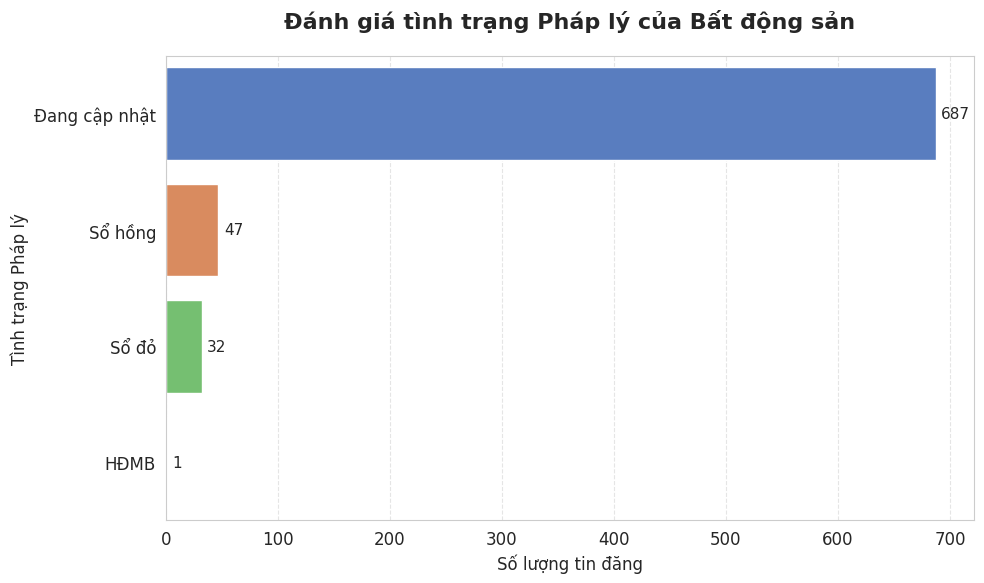

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán số lượng và sắp xếp
legal_counts = df['phap_ly'].value_counts()

# 2. Cấu hình biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột
# Lưu ý: Chúng ta dùng order để đảm bảo 'Đang cập nhật' luôn xuất hiện đầu tiên/nổi bật
ax = sns.countplot(y='phap_ly', data=df,
                   order=legal_counts.index,
                   palette='muted',
                   edgecolor='white')

# 3. Thêm số liệu lên biểu đồ (Annotation)
for i in ax.patches:
    ax.text(i.get_width() + 5, i.get_y() + i.get_height()/2,
            str(int(i.get_width())),
            va='center', fontsize=11)

# 4. Tinh chỉnh
plt.title('Đánh giá tình trạng Pháp lý của Bất động sản', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Số lượng tin đăng', fontsize=12)
plt.ylabel('Tình trạng Pháp lý', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Sự mất cân xứng dữ liệu (Data Imbalance)

Thực trạng: Điểm nhấn lớn nhất của biểu đồ là sự chiếm ưu thế tuyệt đối của nhãn "Đang cập nhật" với 687 tin đăng, áp đảo hoàn toàn so với các loại hình pháp lý minh bạch khác (Sổ hồng, Sổ đỏ, HĐMB).

Nhận xét: Điều này phản ánh một đặc trưng rất rõ nét của thị trường bất động sản tự do: sự thiếu minh bạch thông tin trong giai đoạn quảng bá hoặc đăng tin. Phần lớn người bán chưa công khai hoặc chưa hoàn tất thủ tục pháp lý để đưa lên sàn giao dịch, khiến thông tin về tính pháp lý bị "bỏ ngỏ".

Rủi ro và thách thức trong bài toán định giá

Rủi ro cho mô hình: Vì 90% dữ liệu (687/767) nằm ở nhóm "Đang cập nhật", mô hình học máy của chúng ta sẽ gặp khó khăn lớn khi cố gắng "học" mối tương quan giữa Pháp lý và Giá. Vì đa số dữ liệu là không xác định, mô hình có thể không nhận diện được sự chênh lệch giá trị giữa một bất động sản đã có sổ so với một bất động sản chưa rõ pháp lý.

Gợi ý xử lý:

Không nên loại bỏ cột này, nhưng cần coi nó như một biến phân loại (categorical feature) có độ nhiễu cao.

Nên tạo một nhóm "Pháp lý rõ ràng" (gộp Sổ hồng, Sổ đỏ, HĐMB) để đối trọng với nhóm "Pháp lý chưa rõ ràng" (Đang cập nhật). Việc gom nhóm này sẽ giúp mô hình dễ dàng học được "độ tin cậy" của bất động sản.



/tmp/ipykernel_10682/1249478161.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='huong', data=df,


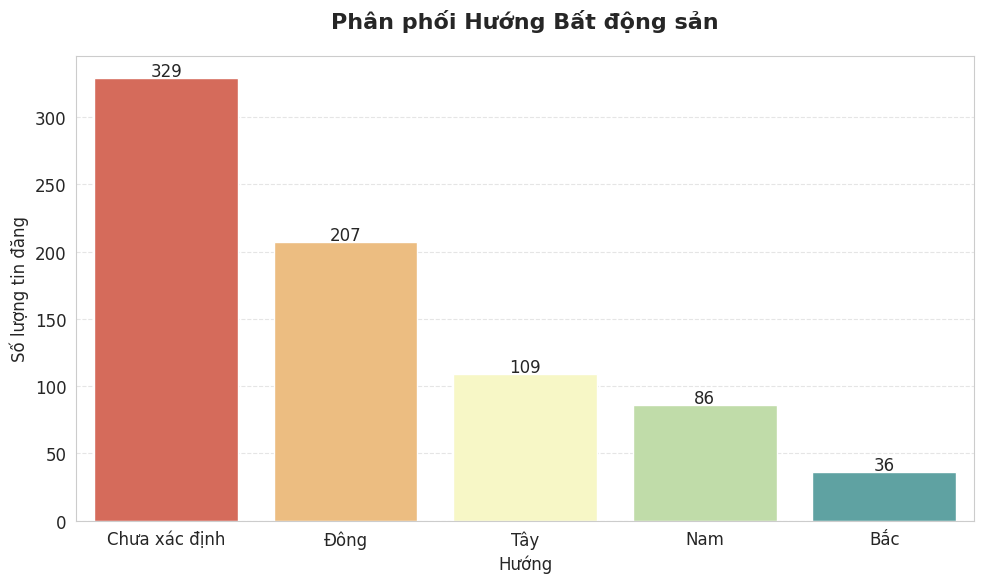

In [29]:
# 1. Tính toán số lượng và sắp xếp theo tần suất
huong_counts = df['huong'].value_counts()

# 2. Cấu hình biểu đồ
plt.figure(figsize=(10, 6))

# Vẽ biểu đồ cột
ax = sns.countplot(x='huong', data=df,
                   order=huong_counts.index,
                   palette='Spectral',
                   edgecolor='white')

# 3. Thêm số liệu lên đầu cột
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 5), textcoords='offset points')

# 4. Tinh chỉnh giao diện
plt.title('Phân phối Hướng Bất động sản', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Hướng', fontsize=12)
plt.ylabel('Số lượng tin đăng', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Chiếm ưu thế bởi nhóm "Chưa xác định":

Nhóm "Chưa xác định" chiếm tỷ trọng lớn nhất với 329 tin đăng, tương đương gần 43% tổng số lượng. Điều này cho thấy một tỷ lệ rất lớn các bất động sản chưa được công khai hoặc chưa được phân loại rõ ràng về hướng trong dữ liệu này.

Sự phân bố của các hướng xác định:

Trong số các bất động sản đã xác định được hướng, hướng Đông là phổ biến nhất (207 tin), vượt xa các hướng còn lại. Điều này có thể phản ánh tâm lý người mua/bán ưu tiên bất động sản hướng Đông (thường được coi là mát mẻ vào buổi sáng và đón nắng tốt).

Hướng Bắc ít phổ biến nhất:

Số lượng tin đăng có hướng Bắc thấp nhất (chỉ 36 tin). Điều này khá phổ biến trong thị trường bất động sản vì hướng Bắc thường bị coi là ít đón nắng (đặc biệt là ở Bắc bán cầu) và có thể gây lạnh hơn vào mùa đông.

Xu hướng giảm dần:
Số lượng tin đăng có xu hướng giảm dần theo thứ tự: Đông > Tây > Nam > Bắc.



/tmp/ipykernel_10682/1469228584.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


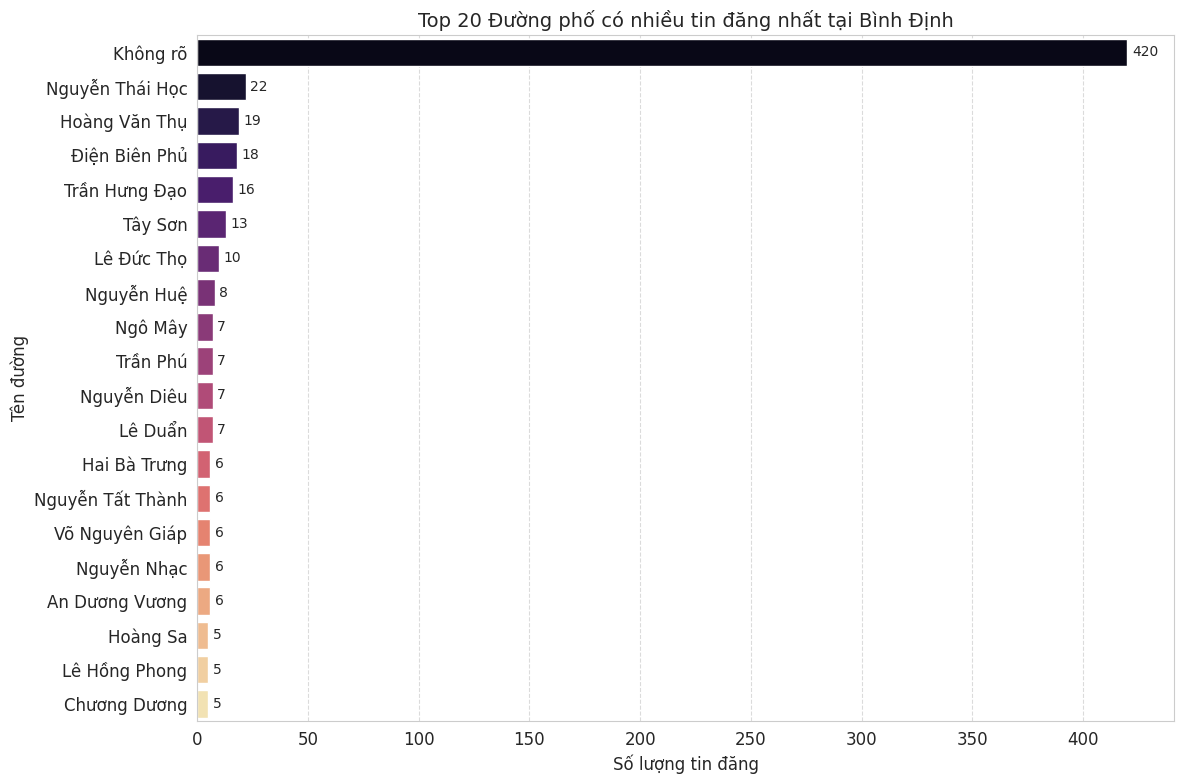

In [30]:
top_20_streets = df['ten_duong'].value_counts().head(20).index

# 3. Vẽ biểu đồ Count plot cho Nhóm 4 (Biến phân loại)
plt.figure(figsize=(12, 8))
sns.countplot(
    data=df[df['ten_duong'].isin(top_20_streets)],
    y='ten_duong',
    order=top_20_streets,
    palette='magma'
)

# 4. Thêm các thông tin bổ trợ cho biểu đồ
# Sau khi vẽ bằng sns.countplot, bạn thêm đoạn này:
ax = plt.gca()
for p in ax.patches:
    width = p.get_width()
    plt.text(width + 2, p.get_y() + p.get_height()/2,
             f'{int(width)}', ha='left', va='center', fontsize=10)
plt.title('Top 20 Đường phố có nhiều tin đăng nhất tại Bình Định', fontsize=14)
plt.xlabel('Số lượng tin đăng', fontsize=12)
plt.ylabel('Tên đường', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


"Điểm đen" về thông tin (Vấn đề "Không rõ")

Hiện tượng: Cột "Không rõ" chiếm ưu thế áp đảo với 420 tin đăng, vượt xa tổng của 19 con đường còn lại cộng lại.

Đây là một phát hiện cực kỳ quan trọng về chất lượng dữ liệu. Con số 420 cho thấy phần lớn dữ liệu đang ở trạng thái thiếu hụt định vị chính xác. Điều này không chỉ gây khó khăn cho việc định giá chi tiết mà còn phản ánh một thói quen đăng tin "lười" hoặc thiếu thông tin minh bạch trên các sàn giao dịch. Khi phân tích, bạn cần nhấn mạnh rằng mô hình định giá dựa trên vị trí (đường phố) sẽ bị hạn chế độ chính xác cho hơn 50% dữ liệu này.

Định danh các "Trục xương sống" thị trường

Nhóm dẫn đầu (Nguyễn Thái Học, Hoàng Văn Thụ, Điện Biên Phủ): Đây chính là các trục đường huyết mạch tại TP. Quy Nhơn. Sự xuất hiện của chúng trong Top đầu phản ánh mật độ dân cư cao và sự tập trung các tiện ích đô thị.

Đặc tính kinh doanh: Các con đường như Trần Hưng Đạo, Tây Sơn, An Dương Vương (thường gắn với view biển hoặc kinh doanh sầm uất) là minh chứng cho thấy nguồn cung tập trung vào phân khúc bất động sản giá trị cao, có khả năng khai thác dòng tiền (cho thuê, kinh doanh, hoặc lưu trú du lịch).

Phân bổ rải rác ở Top cuối

Hiện tượng: Các con đường từ vị trí thứ 10 trở đi có số lượng tin đăng rất thấp (chỉ khoảng 5-7 tin).

Nhận xét: Thị trường tại Bình Định/Quy Nhơn có đặc điểm là phân tán. Ngoài các trục đường chính kể trên, nguồn cung còn lại nằm rải rác ở rất nhiều tuyến đường nhỏ, hẻm nhỏ. Điều này giải thích tại sao dữ liệu của bạn có độ nhiễu cao: vì sự chênh lệch giá giữa "đường chính" và "hẻm nhỏ" là rất lớn, dù chúng có thể ở cùng một phường/quận.

# Phân tích nhị biến (Bivariate Analysis)

1. Phân tích biến số với biến mục tiêu (Numerical vs Target)

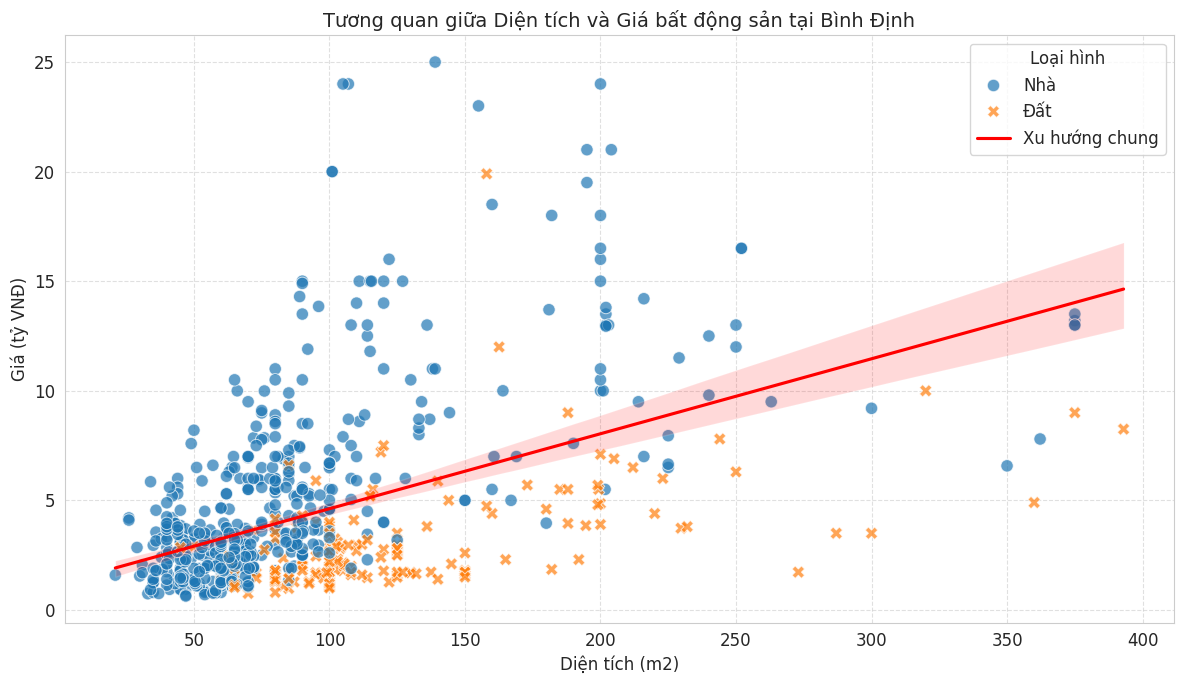

In [31]:
# 2. Vẽ biểu đồ Scatter Plot cho Phân tích nhị biến
plt.figure(figsize=(12, 7))

# Sử dụng màu sắc (hue) để phân biệt giữa Nhóm Nhà và Đất
sns.scatterplot(
    data=df,
    x='dien_tich(m2)',
    y='gia(ty)',
    hue='nhom_bds_lon',
    style='nhom_bds_lon',
    alpha=0.7,
    s=80
)

# Thêm đường hồi quy để kiểm tra tính tuyến tính (tùy chọn)
sns.regplot(
    data=df,
    x='dien_tich(m2)',
    y='gia(ty)',
    scatter=False,
    color='red',
    label='Xu hướng chung'
)

# 3. Cấu hình các thông số hiển thị
plt.title('Tương quan giữa Diện tích và Giá bất động sản tại Bình Định', fontsize=14)
plt.xlabel('Diện tích (m2)', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Loại hình')

# Giới hạn trục tọa độ để quan sát rõ hơn vùng 75% dữ liệu (dưới 104.65 m2)
# plt.xlim(0, 200) # Bạn có thể bỏ comment dòng này nếu muốn zoom vào khu dân dụng

plt.tight_layout()
plt.show()



Xu hướng (Đường hồi quy màu đỏ)Tương quan thuận: Đường hồi quy cho thấy một xu hướng tăng dần đều: Diện tích tăng thì giá bán cũng tăng.
Tuy nhiên, dải màu hồng xung quanh đường hồi quy (độ lệch chuẩn) khá rộng, đặc biệt ở vùng diện tích lớn.

Nhận xét: Điều này cho thấy mặc dù diện tích là yếu tố tiên quyết, nhưng giá trị của bất động sản bị phân tán mạnh do các yếu tố khác như vị trí (đường lớn/hẻm), pháp lý, hoặc tiện ích xung quanh. Diện tích càng lớn thì biên độ giá càng khó dự báo chính xác chỉ bằng thông số m².2.

Sự phân hóa thị trường (Nhóm Nhà vs. Nhóm Đất)Nhóm Nhà (Chấm tròn xanh): Tập trung dày đặc ở vùng diện tích dưới 200 $m^2$. Các điểm này có giá trị (tỷ đồng) rất cao so với diện tích. Đây là phân khúc bất động sản đã có công trình, vị trí nội đô, nhà mặt phố, nơi giá trị đất và nhà ở được cộng hưởng.

Nhóm Đất (Dấu nhân cam): Thường nằm ở vùng diện tích tương đương hoặc lớn hơn nhưng mức giá (tỷ đồng) lại thấp hơn hẳn so với nhóm Nhà.

Ý nghĩa: Biểu đồ này chứng minh một luận điểm quan trọng cho mô hình định giá: "Giá trị đơn vị ($/m^2$) của Nhà ở cao hơn nhiều so với Đất nền". Sự phân tách này là bằng chứng rõ nhất để bạn khẳng định việc cần tách biệt hai nhóm này trong mô hình dự báo.

Nhận diện các "Điểm ngoại lai" (Outliers) và tiềm năng

Điểm trên cao (Góc trái/giữa trên): Có những căn nhà diện tích dưới 100 $m^2$ nhưng có giá từ 15-25 tỷ đồng. Đây chính là các bất động sản "vàng" (mặt tiền, vị trí trung tâm, thương mại).

Điểm dưới thấp (Góc phải dưới): Có những lô đất diện tích lớn (>300 $m^2$) nhưng giá chỉ bằng hoặc thấp hơn những căn nhà diện tích nhỏ. Đây là nhóm đất ở vùng ven, các dự án mới, hoặc đất có tiềm năng dài hạn nhưng chưa khai thác kinh doanh mạnh.

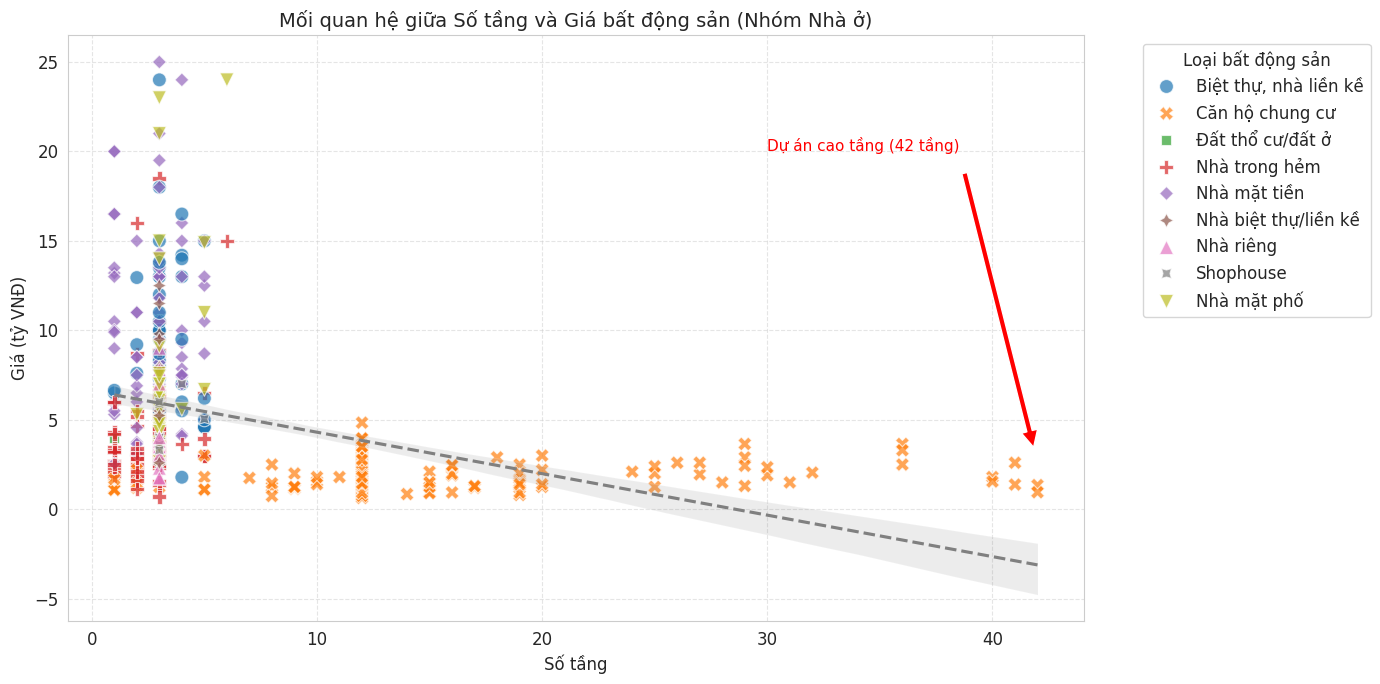

In [32]:
# 2. Sử dụng tập dữ liệu house_df (đã lọc các tin có công trình)
house_df = df[(df['so_tang'] > 0) &
              (df['so_phong_ngu'] > 0) &
              (df['so_wc'] > 0)].copy()

# 3. Vẽ biểu đồ Scatter Plot
plt.figure(figsize=(14, 7))

sns.scatterplot(
    data=house_df,
    x='so_tang',
    y='gia(ty)',
    hue='loai_bds',
    style='loai_bds',
    s=100,
    alpha=0.7
)

# 4. SỬA LỖI TẠI ĐÂY: Sử dụng line_kws để truyền linestyle
sns.regplot(
    data=house_df,
    x='so_tang',
    y='gia(ty)',
    scatter=False,
    color='gray',
    line_kws={'linestyle': '--'} # Kiểu đường được đưa vào đây
)

# 5. Chú thích các điểm ngoại lai (Outliers) - Căn hộ 42 tầng [3]
plt.annotate('Dự án cao tầng (42 tầng)',
             xy=(42, 2.6), # Tọa độ căn hộ Sailing/TMS thường quanh mức giá này [4, 5]
             xytext=(30, 20),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=11, color='red')

# 6. Cấu hình hiển thị
plt.title('Mối quan hệ giữa Số tầng và Giá bất động sản (Nhóm Nhà ở)', fontsize=14)
plt.xlabel('Số tầng', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Loại bất động sản', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Phân hóa rõ rệt giữa hai phân khúc: Nhà phố thấp tầng vs. Chung cư cao tầng
Phân khúc nhà phố thấp tầng (1-7 tầng): Đây là tập hợp dữ liệu dày đặc nhất nằm ở phía bên trái biểu đồ. Phân khúc này có mức giá (tỷ đồng) biến động cực kỳ lớn (từ 1 đến 25 tỷ).

Nhận xét: Điều này cho thấy tại các căn nhà thấp tầng, Số tầng không phải là biến số duy nhất quyết định giá. Các yếu tố như vị trí (mặt tiền đường lớn), diện tích đất và mục đích sử dụng (kinh doanh) đóng vai trò quyết định mức giá chênh lệch cực lớn giữa các bất động sản cùng số tầng.

Phân khúc chung cư cao tầng (>10 tầng): Các điểm đánh dấu màu cam ("x" - Căn hộ chung cư) dàn trải từ tầng 10 đến trên 40 tầng với mức giá khá ổn định (thường dưới 5 tỷ).

Nhận xét: Đây là phân khúc có đơn giá dự báo ổn định hơn. Giá căn hộ thường phụ thuộc vào tầng cao (view, độ thoáng) và diện tích căn hộ, chứ không biến động khủng khiếp như nhà phố.

Sự nghịch lý trong đường xu hướng (Trendline)
Hiện tượng: Đường xu hướng màu xám có độ dốc âm (hướng xuống).

Giải thích logic: Đường xu hướng này bị "lôi kéo" xuống phía dưới bởi các dự án chung cư cao tầng. Vì các căn hộ dù ở tầng rất cao (hơn 40 tầng) nhưng vẫn có giá bán (tỷ đồng) thấp hơn rất nhiều so với những căn nhà phố 4-5 tầng ở vị trí đắc địa.

Cảnh báo cho mô hình định giá: Đường xu hướng này không phản ánh giá trị tăng thêm theo chiều cao của nhà phố. Nếu bạn dùng chung một mô hình hồi quy cho cả "Nhà phố" và "Chung cư", mô hình sẽ dự báo sai hoàn toàn.

Điểm lưu ý về dự án cao tầng
Chú thích đỏ (Dự án 42 tầng): Việc bạn chỉ ra dự án cao tầng là điểm nhấn rất giá trị. Nó cho thấy đây là những tài sản có số lượng đơn vị lớn, nhưng về mặt định giá từng đơn vị, nó tạo thành một phân khúc "phẳng" (giá không tăng theo tầng theo kiểu lũy tiến).

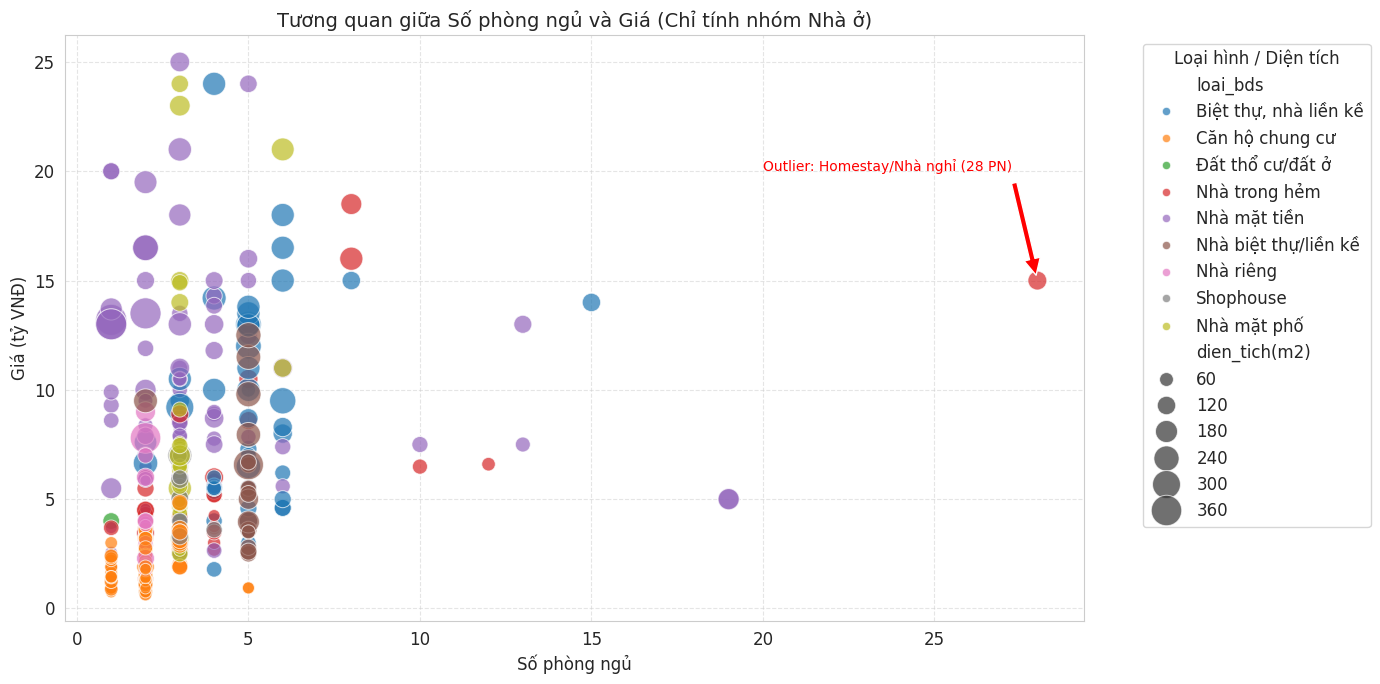

In [33]:
# 1. Sử dụng house_df bạn đã tạo để vẽ biểu đồ
plt.figure(figsize=(14, 7))

# 2. Vẽ biểu đồ Scatter Plot để xem phân phối giá theo số phòng ngủ
sns.scatterplot(
    data=house_df,
    x='so_phong_ngu',
    y='gia(ty)',
    hue='loai_bds',  # Phân biệt Căn hộ, Nhà riêng, Biệt thự...
    size='dien_tich(m2)', # Kích thước điểm thể hiện diện tích
    sizes=(50, 500),
    alpha=0.7
)

# 3. Thêm các thông số hiển thị
plt.title('Tương quan giữa Số phòng ngủ và Giá (Chỉ tính nhóm Nhà ở)', fontsize=14)
plt.xlabel('Số phòng ngủ', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Chú thích điểm ngoại lai đặc biệt (Outlier 28 phòng ngủ)
plt.annotate('Outlier: Homestay/Nhà nghỉ (28 PN)',
             xy=(28, 15), xytext=(20, 20),
             arrowprops=dict(facecolor='red', shrink=0.05),
             fontsize=10, color='red')

plt.legend(title='Loại hình / Diện tích', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Phân khúc nhà ở dân dụng chiếm ưu thế

Tập trung: Đại đa số các bất động sản nằm trong khoảng từ 2 đến 5 phòng ngủ. Đây là cấu hình "tiêu chuẩn" phục vụ nhu cầu ở thực của các hộ gia đình Việt Nam.

Mức giá: Ở dải này, sự phân hóa giá là rất lớn (từ dưới 5 tỷ đến 25 tỷ), cho thấy giá trị bất động sản ở phân khúc này phụ thuộc nhiều vào yếu tố khác (vị trí, thiết kế, tên đường) thay vì chỉ số lượng phòng ngủ.

Sự hiện diện của "Tài sản thương mại" (Outliers)

Phát hiện: Điểm dữ liệu tại mức 28 phòng ngủ (được chú thích là Homestay/Nhà nghỉ) nằm hoàn toàn tách biệt so với phần còn lại.

Nhận xét: Đây không phải là nhà ở thuần túy mà là bất động sản khai thác dòng tiền. Việc chấm tròn này có kích thước không quá lớn (diện tích không quá khủng) nhưng giá bán ở mức 15 tỷ cho thấy giá trị của nó được định đoạt bởi khả năng kinh doanh dịch vụ lưu trú.

Mối liên hệ với diện tích (Kích thước chấm tròn)
Quy luật: Có thể thấy các chấm tròn có diện tích lớn (kích thước to) thường tập trung ở nhóm 3-5 phòng ngủ và mức giá từ 5-15 tỷ.

Sự ổn định: Các căn hộ/nhà ở có diện tích lớn đi kèm số phòng ngủ hợp lý (3-5 phòng) thường có mức giá "dễ chịu" hơn so với các căn hộ diện tích nhỏ ở vị trí đắc địa (chấm tròn nhỏ nhưng nằm ở vị trí cao). Điều này chứng minh rằng tại Bình Định, vị trí (location) có trọng số ảnh hưởng đến giá cao hơn nhiều so với tổng số lượng phòng ngủ.



/tmp/ipykernel_10682/3515388164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='so_wc', y='gia(ty)', data=house_df, palette='coolwarm')


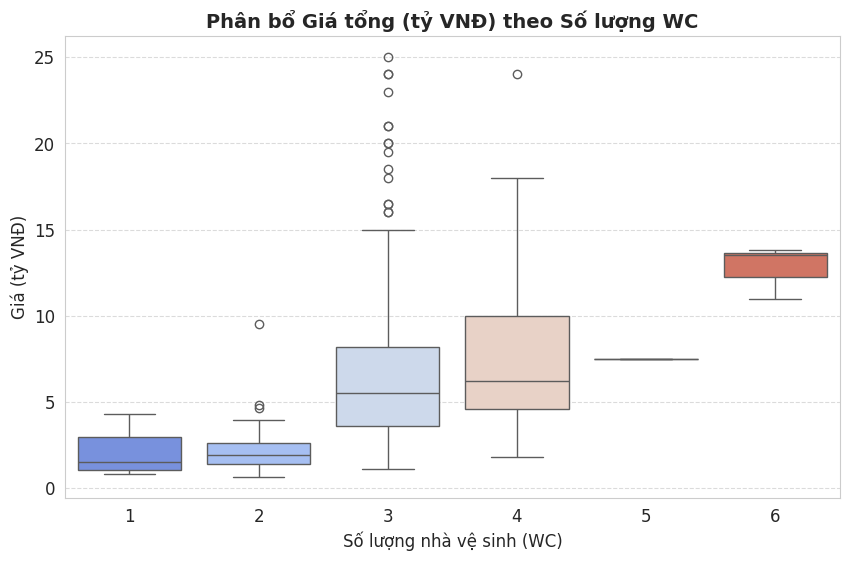

In [34]:
# Sử dụng house_df (lọc bỏ so_wc = 0) để biểu đồ tập trung vào nhà ở
plt.figure(figsize=(10, 6))
sns.boxplot(x='so_wc', y='gia(ty)', data=house_df, palette='coolwarm')

plt.title('Phân bổ Giá tổng (tỷ VNĐ) theo Số lượng WC', fontsize=14, fontweight='bold')
plt.xlabel('Số lượng nhà vệ sinh (WC)')
plt.ylabel('Giá (tỷ VNĐ)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Biểu đồ "Phân bổ Giá tổng (tỷ VNĐ) theo Số lượng WC" cho thấy mối quan hệ tỉ lệ thuận giữa quy mô tiện ích và giá trị bất động sản:

Xu hướng tăng dần: Giá trị bất động sản tăng rõ rệt theo số lượng nhà vệ sinh (WC). Các tài sản có 1-2 WC thường thuộc phân khúc giá thấp (dưới 5 tỷ VNĐ), trong khi các tài sản có 4-6 WC đều nằm ở phân khúc giá cao, thường trên 5 tỷ VNĐ.

Sự phân hóa ở mức 3 WC: Nhóm nhà ở có 3 WC có dải giá rất rộng và nhiều điểm ngoại lai (outliers). Điều này cho thấy đây là phân khúc phổ biến nhất, nơi sự chênh lệch về vị trí hoặc loại hình bất động sản tạo ra sự khác biệt lớn về giá, dù cùng một số lượng phòng WC.

Giá trị của phân khúc cao cấp: Đối với các tài sản có 6 WC, mức giá tối thiểu đã vượt ngưỡng 10 tỷ VNĐ, khẳng định đây là phân khúc dành cho bất động sản cao cấp, biệt thự hoặc nhà phố diện tích lớn.

Độ biến động: Số lượng WC càng lớn (từ 4 trở lên), giá trị bất động sản càng trở nên ổn định ở mức cao, thay vì biến động mạnh như nhóm 1-3 WC.

2. Phân tích biến phân loại với biến mục tiêu (Categorical vs Target)

/tmp/ipykernel_10682/3578867885.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


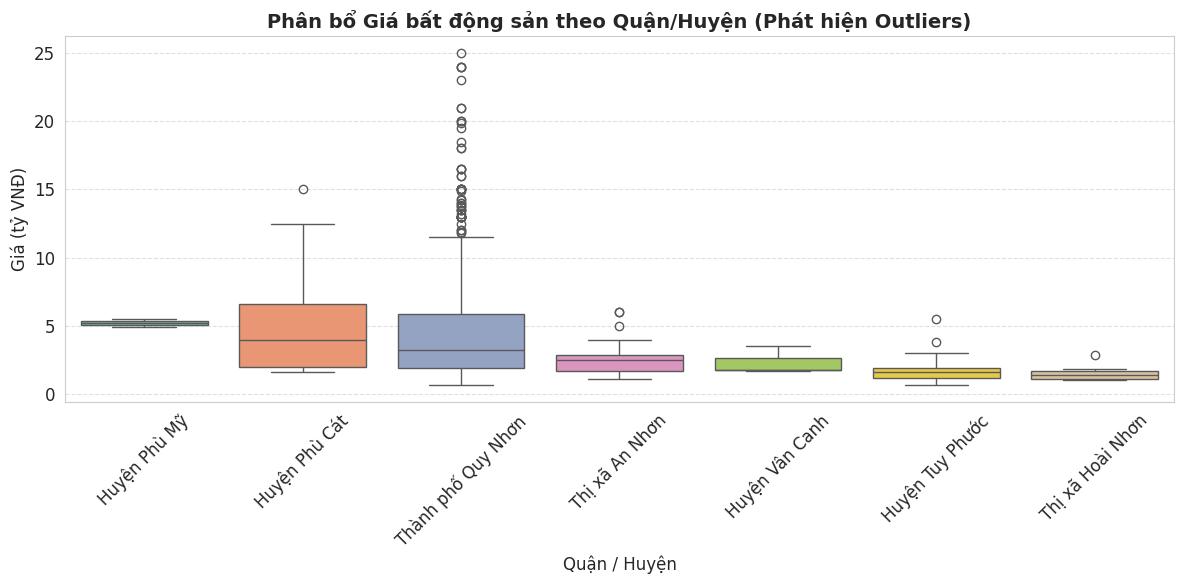

In [35]:
# Tính toán thứ tự sắp xếp theo giá trung bình từ cao đến thấp để biểu đồ logic hơn
order = df.groupby('quan_huyen')['gia(ty)'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='quan_huyen',
    y='gia(ty)',
    order=order,
    palette='Set2'
)
plt.title('Phân bổ Giá bất động sản theo Quận/Huyện (Phát hiện Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Quận / Huyện', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.xticks(rotation=45) # Xoay nhãn để dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này tiết lộ cấu trúc phân bổ giá thực tế thay vì chỉ nhìn vào con số trung bình:

Sự phân hóa cực đoan tại Thành phố Quy Nhơn: Đây là khu vực có "dải" phân bổ giá dài nhất, đi kèm với rất nhiều điểm ngoại lai (Outliers - các chấm tròn phía trên). Điều này khẳng định thị trường Quy Nhơn cực kỳ đa dạng: từ nhà đất giá rẻ trong hẻm đến các biệt thự/shophouse cao cấp trị giá hàng chục tỷ đồng.

Tính ổn định tại các huyện: Ngược lại, tại các thị xã như Hoài Nhơn hay huyện Tuy Phước, hộp (box) rất hẹp, cho thấy mức giá bất động sản tại đây khá đồng nhất và ổn định. Người mua tại các khu vực này ít gặp phải tình trạng "mua hớ" do biến động giá bất ngờ.

Hiện tượng "Huyện Phù Mỹ & Phù Cát": Dù số lượng tin đăng ít hơn, nhưng biểu đồ Boxplot cho thấy mức giá của các khu vực này lại có những căn có giá trị cao bất thường (ví dụ: Phù Cát có mức giá vươn tới 15 tỷ), gợi ý rằng đây có thể là nơi có các dự án bất động sản nghỉ dưỡng hoặc quy hoạch lớn đang hình thành, đẩy mặt bằng giá trung bình lên cao.

/tmp/ipykernel_10682/1305556020.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


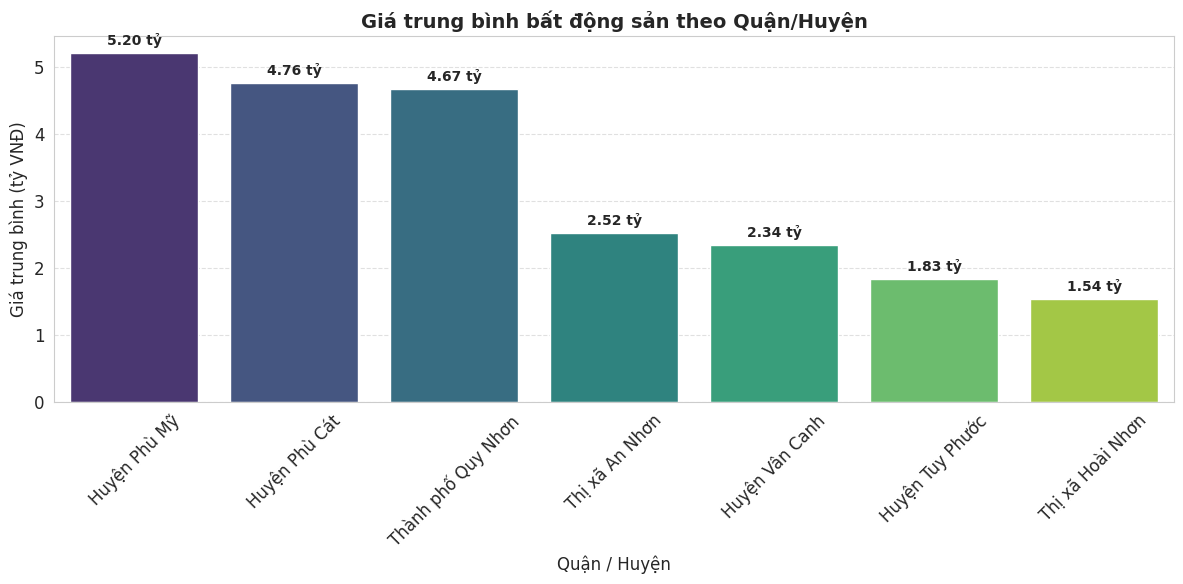

In [36]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df,
    x='quan_huyen',
    y='gia(ty)',
    order=order,
    palette='viridis',
    estimator='mean',
    errorbar=None
)

# Thêm nhãn giá trị lên đầu mỗi cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} tỷ',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.title('Giá trung bình bất động sản theo Quận/Huyện', fontsize=14, fontweight='bold')
plt.xlabel('Quận / Huyện', fontsize=12)
plt.ylabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.xticks(rotation=45) # Xoay nhãn để dễ đọc
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này cung cấp thông tin về "mặt bằng giá" để so sánh nhanh giữa các khu vực:

Sự bất ngờ của nhóm dẫn đầu: Huyện Phù Mỹ và Phù Cát đang có giá trung bình cao hơn cả Thành phố Quy Nhơn.

Lưu ý quan trọng: Bạn cần kiểm tra lại dữ liệu (có thể do các khu vực này có ít tin đăng nhưng lại có vài dự án lớn giá cao, kéo giá trung bình lên). Đây là một "bẫy" dữ liệu phổ biến: Giá trung bình cao không nhất thiết đồng nghĩa với khu vực đó là trung tâm giao dịch sôi động nhất.

Thành phố Quy Nhơn là "Trọng tâm thanh khoản": Mặc dù giá trung bình có thể thấp hơn Phù Mỹ/Phù Cát, nhưng Quy Nhơn là nơi có độ rộng thị trường lớn nhất.

/tmp/ipykernel_10682/3031667204.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='phap_ly', y='gia(ty)', palette='Set2')


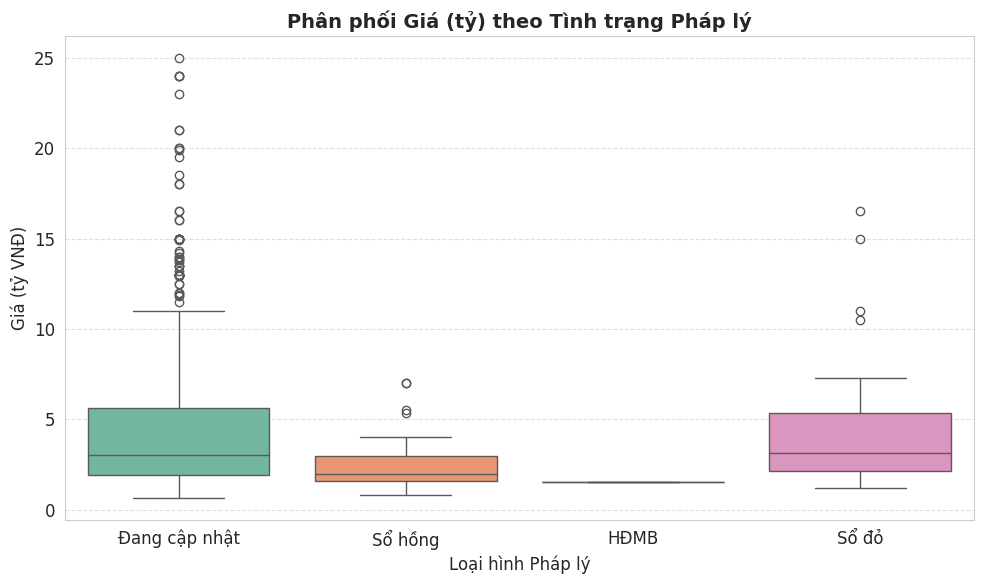

In [46]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='phap_ly', y='gia(ty)', palette='Set2')
plt.title('Phân phối Giá (tỷ) theo Tình trạng Pháp lý', fontsize=14, fontweight='bold')
plt.xlabel('Loại hình Pháp lý', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này phản ánh sự biến động và các trường hợp bất thường của giá theo pháp lý:

Nhóm "Đang cập nhật" có sự phân hóa mạnh nhất: Đây là nhóm có dải phân phối giá rộng nhất với số lượng điểm ngoại lai (outliers) rất lớn, trải dài từ mức giá thấp đến các tài sản có giá lên tới 25 tỷ VNĐ. Điều này cho thấy đây có thể là phân khúc bao gồm nhiều loại tài sản khác nhau, từ đất nền dự án chưa tách sổ đến các bất động sản cao cấp đang chờ hoàn thiện thủ tục.

Tính ổn định của các nhóm khác: Nhóm "Sổ hồng" và "Sổ đỏ" có dải phân phối tập trung hơn, cho thấy giá trị của các tài sản này có mức độ ổn định và dễ dự báo hơn so với nhóm "Đang cập nhật".

Nhóm HĐMB (Hợp đồng mua bán): Có dải phân phối rất hẹp và giá trị thấp, cho thấy các tài sản này thường thuộc phân khúc thị trường bình dân hoặc căn hộ/dự án mới bắt đầu giao dịch.

/tmp/ipykernel_10682/1633554645.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='phap_ly', y='gia(ty)', palette='viridis', estimator='mean', errorbar=None)


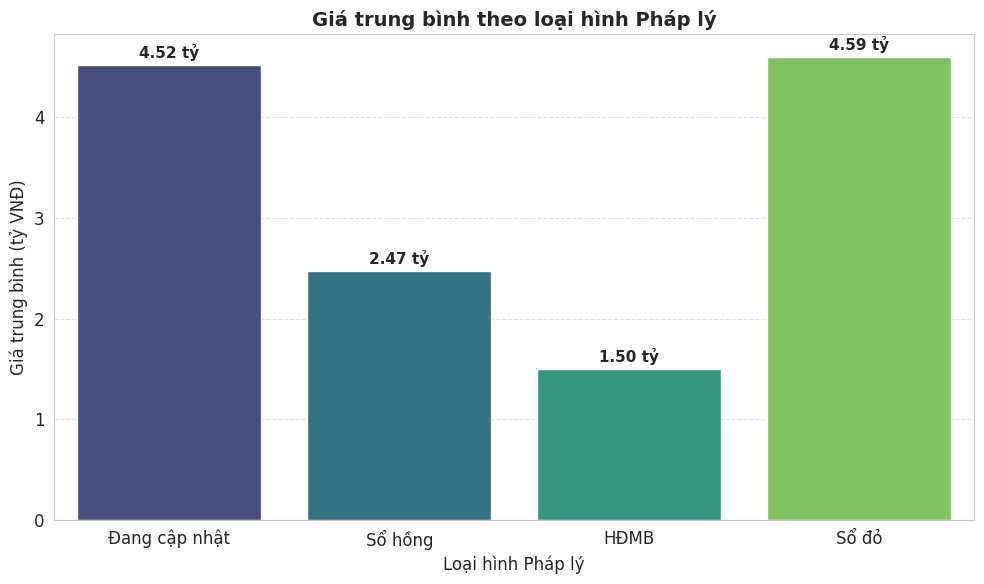

In [47]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='phap_ly', y='gia(ty)', palette='viridis', estimator='mean', errorbar=None)

# Thêm nhãn giá trị trung bình lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} tỷ',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontweight='bold', fontsize=11)

plt.title('Giá trung bình theo loại hình Pháp lý', fontsize=14, fontweight='bold')
plt.xlabel('Loại hình Pháp lý', fontsize=12)
plt.ylabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này cung cấp cái nhìn về mặt bằng giá của từng nhóm pháp lý:

Giá trị tương đương giữa "Sổ đỏ" và "Đang cập nhật": Một phát hiện đáng chú ý là giá trung bình của nhóm "Sổ đỏ" (4.59 tỷ VNĐ) và nhóm "Đang cập nhật" (4.52 tỷ VNĐ) là gần như tương đương nhau.

Thách thức tư duy đầu tư: Thông thường, tài sản có pháp lý hoàn chỉnh (Sổ đỏ) sẽ có giá trị cao hơn. Tuy nhiên, tại đây, nhóm "Đang cập nhật" vẫn giữ mức giá trung bình rất cao, cho thấy người mua tại thị trường này đang đặt trọng tâm lớn vào vị trí và tiềm năng của tài sản, đôi khi chấp nhận rủi ro pháp lý để đổi lấy cơ hội sở hữu bất động sản tại các vị trí đắc địa.

Mức giá của các nhóm còn lại: "Sổ hồng" (2.47 tỷ VNĐ) và "HĐMB" (1.50 tỷ VNĐ) có mức giá trung bình thấp hơn đáng kể, phản ánh đây là các phân khúc bất động sản quy mô nhỏ hơn hoặc nằm ở các khu vực có giá trị khai thác thương mại thấp hơn.

/tmp/ipykernel_10682/3957370467.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


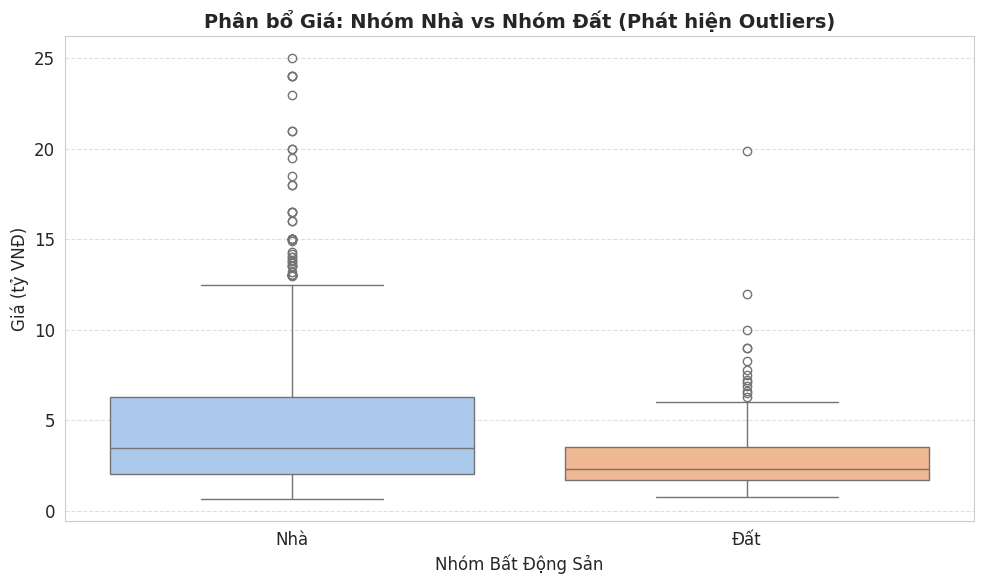

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='nhom_bds_lon',
    y='gia(ty)',
    palette='pastel'
)
plt.title('Phân bổ Giá: Nhóm Nhà vs Nhóm Đất (Phát hiện Outliers)', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Bất Động Sản', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ Boxplot cung cấp cái nhìn về độ ổn định và tính đa dạng của từng nhóm:

Độ biến động (Dispersion): Nhóm "Nhà" có hộp (box) cao hơn và "râu" (whiskers) dài hơn nhiều so với nhóm "Đất". Điều này khẳng định thị trường Nhà ở tại Bình Định có sự phân hóa giá rất mạnh. Người mua nhà phải đối mặt với biên độ giá rộng, phụ thuộc nhiều vào vị trí cụ thể.

Giá trị ngoại lai (Outliers): Nhóm "Nhà" chứa đựng một số lượng lớn các điểm ngoại lai (chấm tròn phía trên), biểu thị cho các tài sản cao cấp, nhà mặt tiền hoặc bất động sản có giá trị đặc biệt cao. Nhóm "Đất" cũng có outliers nhưng ít dày đặc hơn, cho thấy thị trường đất nền có xu hướng "bằng phẳng" hơn về giá.

Điểm hội tụ (Median): Đường trung vị (vạch ngang trong hộp) của nhóm "Nhà" cao hơn nhóm "Đất", chứng tỏ mặt bằng giá chung của phân khúc có nhà ở luôn cao hơn đất nền (điều hiển nhiên do giá trị của công trình xây dựng trên đất).

/tmp/ipykernel_10682/3603898621.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


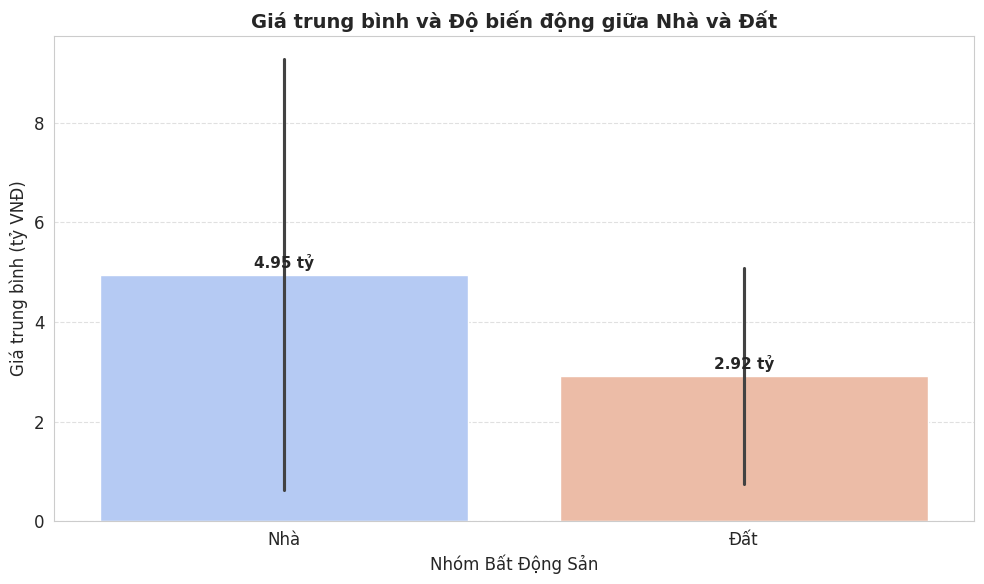

In [38]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df,
    x='nhom_bds_lon',
    y='gia(ty)',
    palette='coolwarm',
    estimator='mean',
    errorbar='sd'
)

# Thêm nhãn giá trị trung bình lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} tỷ',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Giá trung bình và Độ biến động giữa Nhà và Đất', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Bất Động Sản', fontsize=12)
plt.ylabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ Barplot giúp đưa ra kết luận về giá trị trung bình thị trường:

Chênh lệch giá trị: Giá trung bình nhóm "Nhà" (4.95 tỷ) gần gấp đôi nhóm "Đất" (2.92 tỷ). Đây là một chỉ số quan trọng để tư vấn cho nhà đầu tư về phân khúc tài chính cần chuẩn bị.

Độ lệch chuẩn (Error Bars): Các thanh dọc trên đỉnh mỗi cột (độ lệch chuẩn) cho thấy sự biến động thực tế. Thanh sai số của nhóm "Nhà" dài hơn hẳn nhóm "Đất", củng cố cho nhận định rằng: Đầu tư vào nhóm "Nhà" có rủi ro về định giá cao hơn (khó đoán định giá chính xác) so với nhóm "Đất".

/tmp/ipykernel_10682/1538306521.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


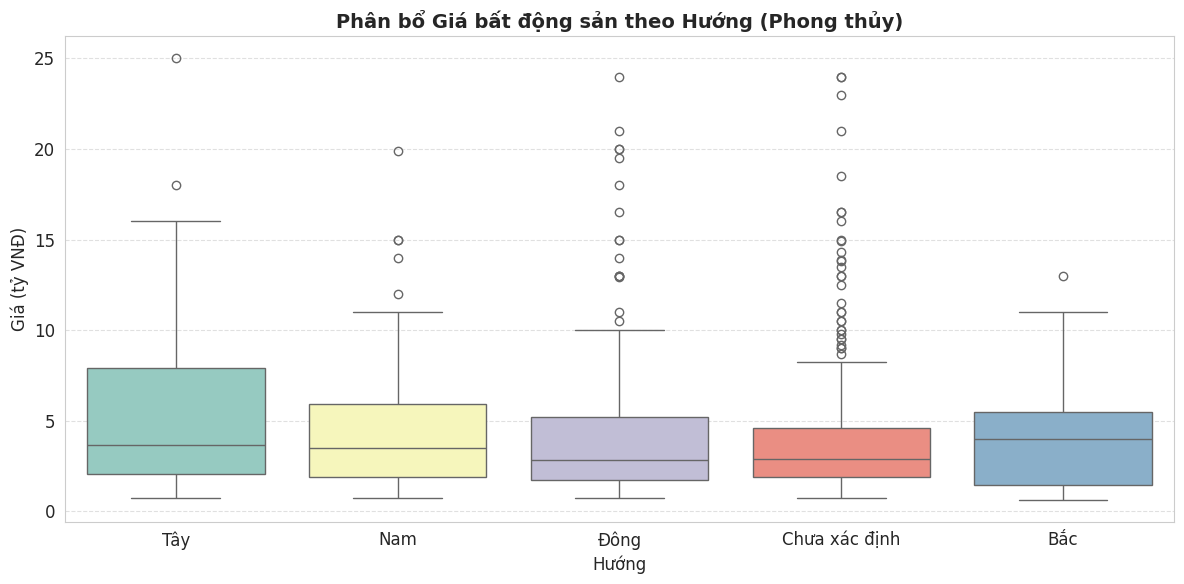

In [39]:
order = df.groupby('huong')['gia(ty)'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df,
    x='huong',
    y='gia(ty)',
    order=order,
    palette='Set3'
)
plt.title('Phân bổ Giá bất động sản theo Hướng (Phong thủy)', fontsize=14, fontweight='bold')
plt.xlabel('Hướng', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này giúp bóc tách giá trị thực của các bất động sản dựa trên hướng mà không bị đánh lừa bởi con số trung bình:

Sự biến động giá (Spread): Biểu đồ cho thấy hướng Đông và Chưa xác định có số lượng điểm ngoại lai (Outliers) cực kỳ dày đặc. Điều này chứng minh rằng tại các hướng này, giá trị bất động sản không đồng nhất. Các căn nhà có giá "trên trời" thường rơi vào các hướng này, có thể do chúng nằm ở vị trí mặt tiền đặc biệt hoặc view biển/trung tâm, vượt ra ngoài quy luật phong thủy thông thường.

Tính đồng nhất của hướng Tây: Nhìn vào hộp của hướng Tây, chúng ta thấy nó có chiều dài lớn nhất, cho thấy đây là hướng có độ biến động giá cao. Điều này có thể giải thích do "hướng Tây" thường bị coi là nóng, nên giá cả thường phải điều chỉnh linh hoạt hơn so với các hướng mát mẻ (như Đông Nam hoặc Đông).

Giá trị trung vị (Median): Các đường gạch ngang ở giữa các hộp khá tương đồng, cho thấy trên mặt bằng chung, thị trường không có sự phân biệt giá quá gay gắt chỉ dựa thuần túy vào hướng.

/tmp/ipykernel_10682/2370813615.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


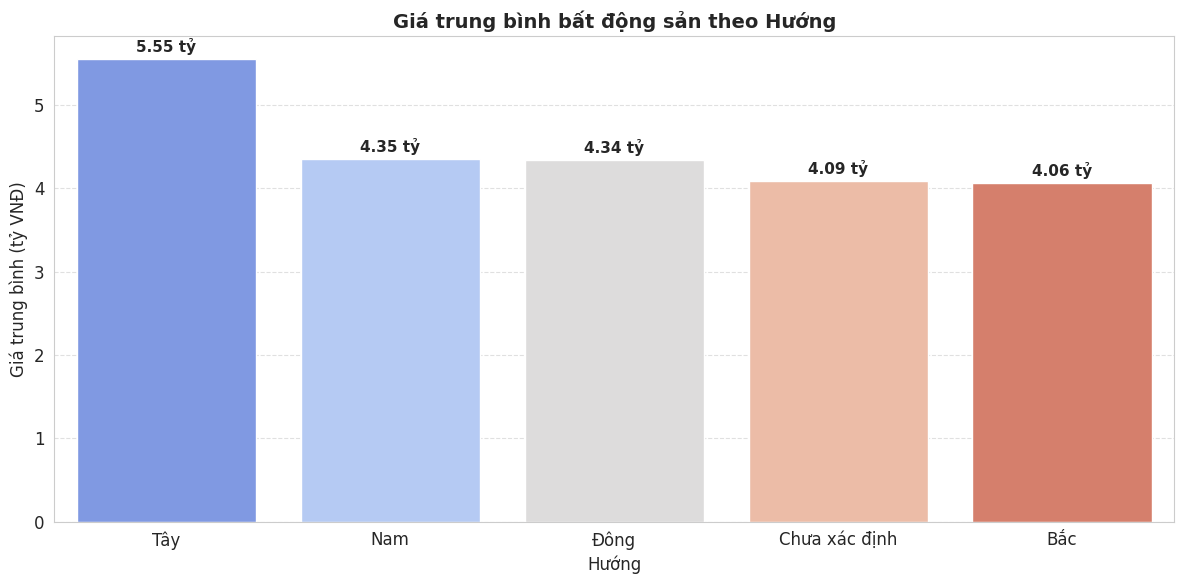

In [40]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=df,
    x='huong',
    y='gia(ty)',
    order=order,
    palette='coolwarm',
    estimator='mean',
    errorbar=None
)

# Thêm nhãn giá trị trung bình lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} tỷ',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Giá trung bình bất động sản theo Hướng', fontsize=14, fontweight='bold')
plt.xlabel('Hướng', fontsize=12)
plt.ylabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Biểu đồ này phản ánh "niềm tin thị trường" vào giá trị các hướng:

Hướng Tây dẫn đầu về giá trung bình: Điểm bất ngờ nhất là hướng Tây đang có giá trung bình cao nhất (5.55 tỷ).

Giải mã: Điều này nghe có vẻ ngược đời với phong thủy truyền thống, nhưng trong bất động sản, hướng Tây thường là hướng có các tuyến đường lớn, mặt tiền kinh doanh sầm uất hoặc quỹ đất gần biển/trung tâm. Vị trí đã áp đảo phong thủy.

Sự cân bằng: Các hướng còn lại (Nam, Đông, Bắc) dao động từ 4.0 - 4.3 tỷ, một mức chênh lệch không đáng kể. Điều này cho thấy khách hàng tại Bình Định có tư duy thực tế: họ sẵn sàng mua bất động sản ở hướng Tây nếu vị trí đó thuận lợi cho kinh doanh.

/tmp/ipykernel_10682/2725914803.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='phap_ly', y='gia(ty)', palette='Set2')


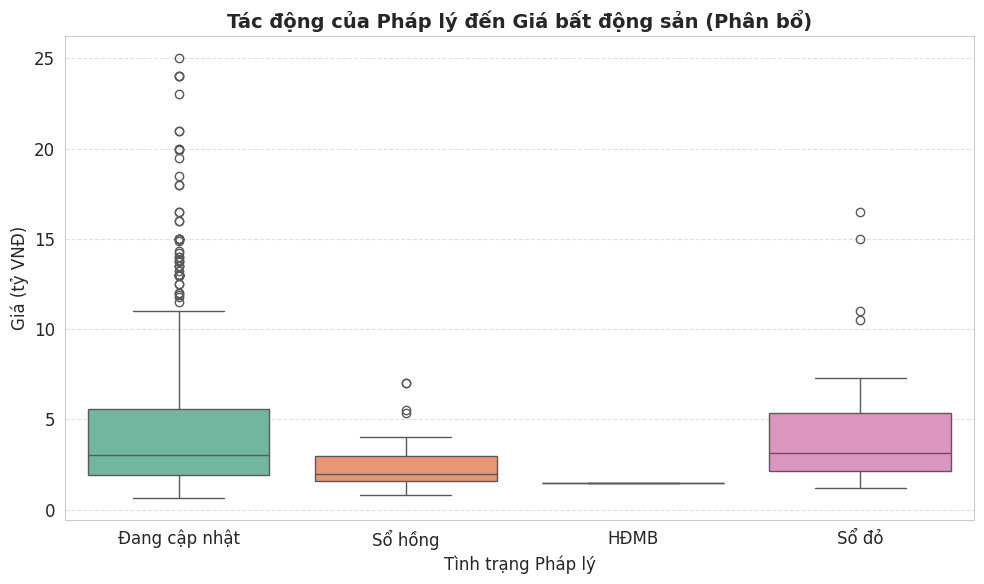

In [41]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='phap_ly', y='gia(ty)', palette='Set2')
plt.title('Tác động của Pháp lý đến Giá bất động sản (Phân bổ)', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng Pháp lý', fontsize=12)
plt.ylabel('Giá (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Sự phân hóa rủi ro: Nhóm "Đang cập nhật" có dải phân bổ giá (boxplot) rộng nhất và mật độ điểm ngoại lai (outliers) dày đặc, với những tài sản lên tới 25 tỷ VNĐ. Điều này cho thấy đây là phân khúc "đầu cơ" cao: rủi ro về pháp lý nhưng lại là nơi tập trung các bất động sản giá trị cao (có thể là nhà mặt tiền hoặc dự án lớn đang chờ sổ).

Tính ổn định: Nhóm "Sổ hồng" có dải phân bổ giá hẹp và ít outliers hơn, cho thấy đây là phân khúc thị trường bình dân hoặc nhà ở ổn định, mức giá ít bị biến động bởi các yếu tố đầu cơ.

Pháp lý "Sổ đỏ": Mặc dù có ít tài sản hơn, nhưng nhóm này vẫn xuất hiện các tài sản ngoại lai (trên 15 tỷ), cho thấy giá trị của "Sổ đỏ" không chỉ nằm ở tính an toàn mà còn ở vị trí của đất.

Pháp lý không chỉ là giấy tờ, nó còn là "bộ lọc" cho loại hình bất động sản. Nhà đầu tư muốn an toàn sẽ chọn "Sổ hồng", trong khi các nhà đầu tư mạo hiểm chấp nhận rủi ro pháp lý để tìm kiếm lợi nhuận từ các tài sản "Đang cập nhật".

/tmp/ipykernel_10682/3962601948.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df, x='phap_ly', y='gia(ty)', palette='viridis', estimator='mean', errorbar=None)


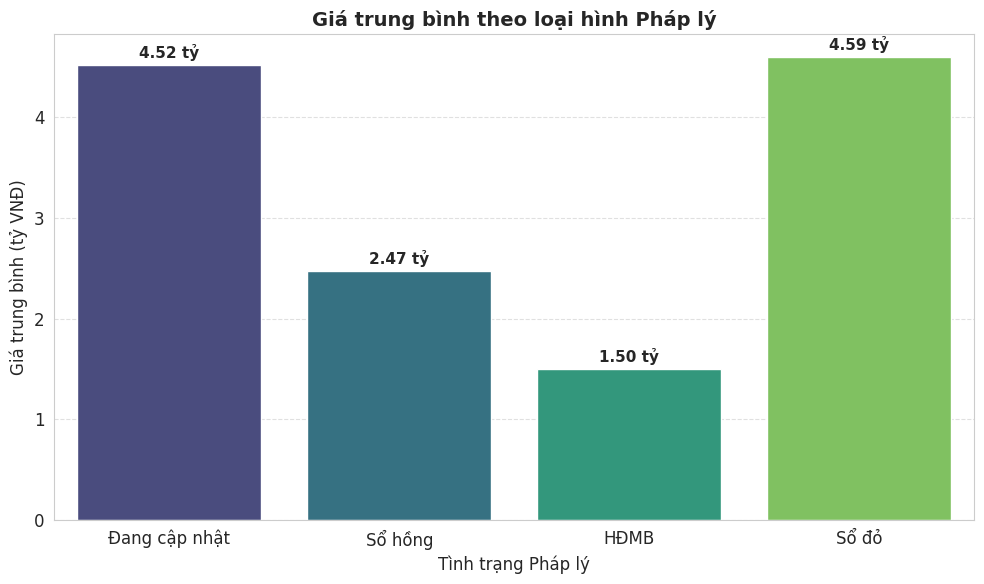

In [42]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=df, x='phap_ly', y='gia(ty)', palette='viridis', estimator='mean', errorbar=None)

# Thêm nhãn giá trị trung bình lên đầu cột
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f} tỷ',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=11, fontweight='bold')

plt.title('Giá trung bình theo loại hình Pháp lý', fontsize=14, fontweight='bold')
plt.xlabel('Tình trạng Pháp lý', fontsize=12)
plt.ylabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Nghịch lý thị trường: Nhóm "Đang cập nhật" (4.52 tỷ) và "Sổ đỏ" (4.59 tỷ) đang dẫn đầu về giá trung bình.

Điểm cần lưu ý: Việc giá trung bình của nhóm "Đang cập nhật" cao ngang ngửa với "Sổ đỏ" là một tín hiệu đặc thù của thị trường Bình Định. Điều này chứng minh rằng người mua đang trả tiền cho vị trí và tiềm năng nhiều hơn là cho sự an toàn pháp lý. Nếu một tài sản có vị trí đẹp, họ sẵn sàng mua ngay cả khi giấy tờ pháp lý chỉ mới "đang cập nhật".

Nhóm thấp giá: Nhóm "Sổ hồng" và "HĐMB" có giá trung bình thấp hơn đáng kể. Điều này có thể giải thích do đây chủ yếu là các căn hộ chung cư hoặc nhà ở diện tích nhỏ, giá trị thấp hơn so với các lô đất nền hoặc nhà phố lớn (nơi thường có sổ đỏ hoặc đang trong quá trình tách thửa/cập nhật).

Mặt bằng giá tại thị trường này không bị phụ thuộc quá nhiều vào tính hoàn thiện của pháp lý. Vị trí địa lý và loại hình bất động sản là những biến số có trọng số ảnh hưởng đến giá cao hơn.

/tmp/ipykernel_10682/2679245492.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


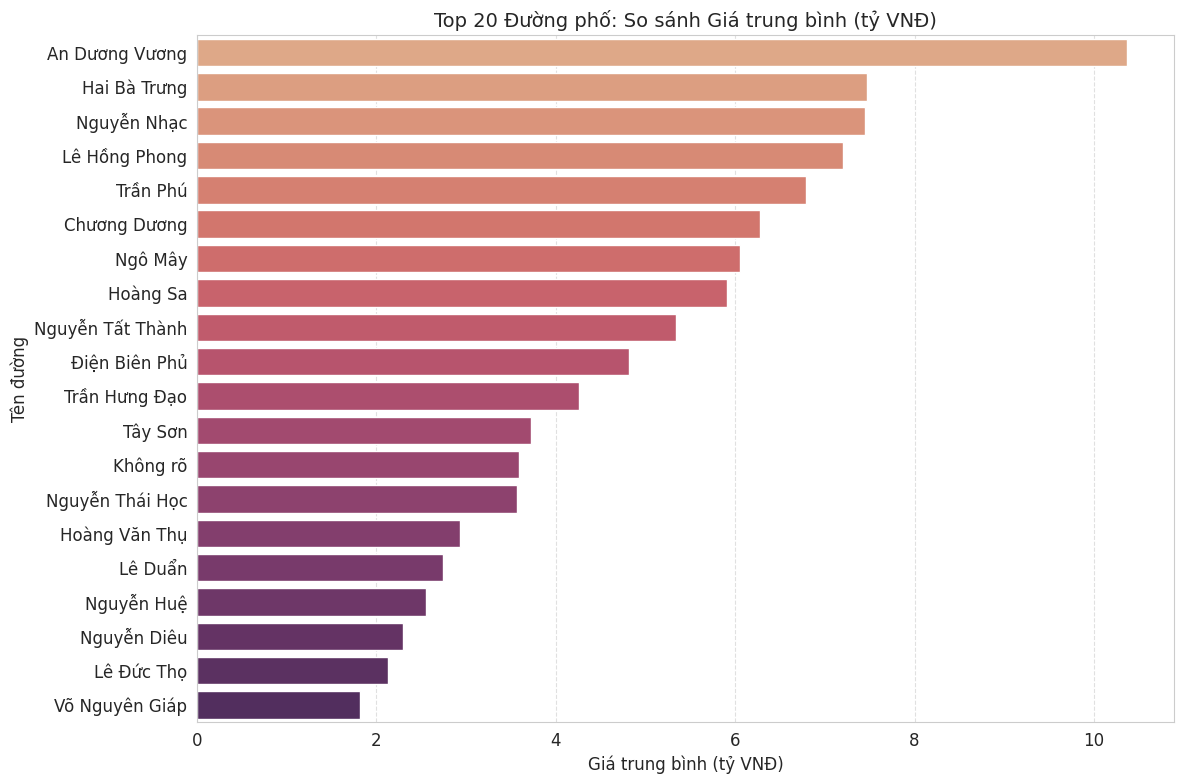

In [43]:
# 1. Lấy danh sách Top 20 đường có nhiều tin đăng nhất
top_20_streets = df['ten_duong'].value_counts().head(20).index
df_top_streets = df[df['ten_duong'].isin(top_20_streets)]

# 2. Sắp xếp thứ tự các đường theo giá trung bình từ cao đến thấp để dễ quan sát
order_price = df_top_streets.groupby('ten_duong')['gia(ty)'].mean().sort_values(ascending=False).index

# 3. Vẽ biểu đồ Bar Plot cho Top 20 đường
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_top_streets,
    y='ten_duong',
    x='gia(ty)',
    order=order_price,
    palette='flare',
    estimator='mean',
    errorbar=None
)

plt.title('Top 20 Đường phố: So sánh Giá trung bình (tỷ VNĐ)', fontsize=14)
plt.xlabel('Giá trung bình (tỷ VNĐ)', fontsize=12)
plt.ylabel('Tên đường', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

"Giá trị vàng" của các tuyến đường

Tuyến đường dẫn đầu: Đường An Dương Vương đang giữ vị trí độc tôn với mức giá trung bình vượt ngưỡng 10 tỷ VNĐ. Đây là minh chứng rõ ràng cho giá trị của các tuyến đường ven biển hoặc trục chính đô thị tại Quy Nhơn/Bình Định – nơi có khả năng kinh doanh dịch vụ và du lịch cao.

Nhóm "Top tier" (Top 5): Các con đường như An Dương Vương, Hai Bà Trưng, Nguyễn Nhạc, Lê Hồng Phong, Trần Phú tạo thành một nhóm các "tuyến phố thương mại cốt lõi". Mức giá ở nhóm này cao vượt trội so với các tuyến còn lại, cho thấy đây là nơi tập trung các bất động sản có tính thanh khoản cao nhất và giá trị tài sản lớn nhất.

Sự phân hóa về phân khúc giá

Sự dốc xuống của đường giá: Biểu đồ có hình dạng "bậc thang" khá rõ rệt. Sự chênh lệch giữa đường đứng đầu (10+ tỷ) và đường đứng thứ 20 (gần 2 tỷ) cho thấy một sự phân hóa rất lớn về chất lượng bất động sản và vị trí giữa các tuyến đường trong cùng một địa phương.

Nhóm "Không rõ": Sự xuất hiện của giá trị "Không rõ" trong Top 20 với mức giá khoảng 3.5 tỷ VNĐ là một tín hiệu cảnh báo. Điều này cho thấy dữ liệu của bạn có một lượng lớn các tin đăng không ghi rõ địa chỉ hoặc tên đường, làm mất đi tính chính xác khi định giá các tài sản này.

Ý nghĩa đối với bài toán định giá và đầu tư

Định giá dựa trên tuyến đường: Biểu đồ này khẳng định "Tên đường" (Location) là biến số quan trọng nhất trong mô hình định giá tại Bình Định. Để định giá một bất động sản, việc đầu tiên là phải xác định nó nằm trên tuyến đường nào, sau đó mới xét đến các yếu tố khác (diện tích, pháp lý).

Chiến lược đầu tư: Nếu nhà đầu tư muốn tìm kiếm tài sản có giá trị "bền vững", họ nên tập trung vào nhóm 5-7 tuyến đường đầu tiên. Ngược lại, nếu muốn tìm kiếm "vùng trũng" để chờ tăng giá, họ nên nhắm vào các con đường có tiềm năng phát triển nhưng chưa nằm trong Top 10.

3. Phân tích tương quan đa biến (Multivariate Analysis)

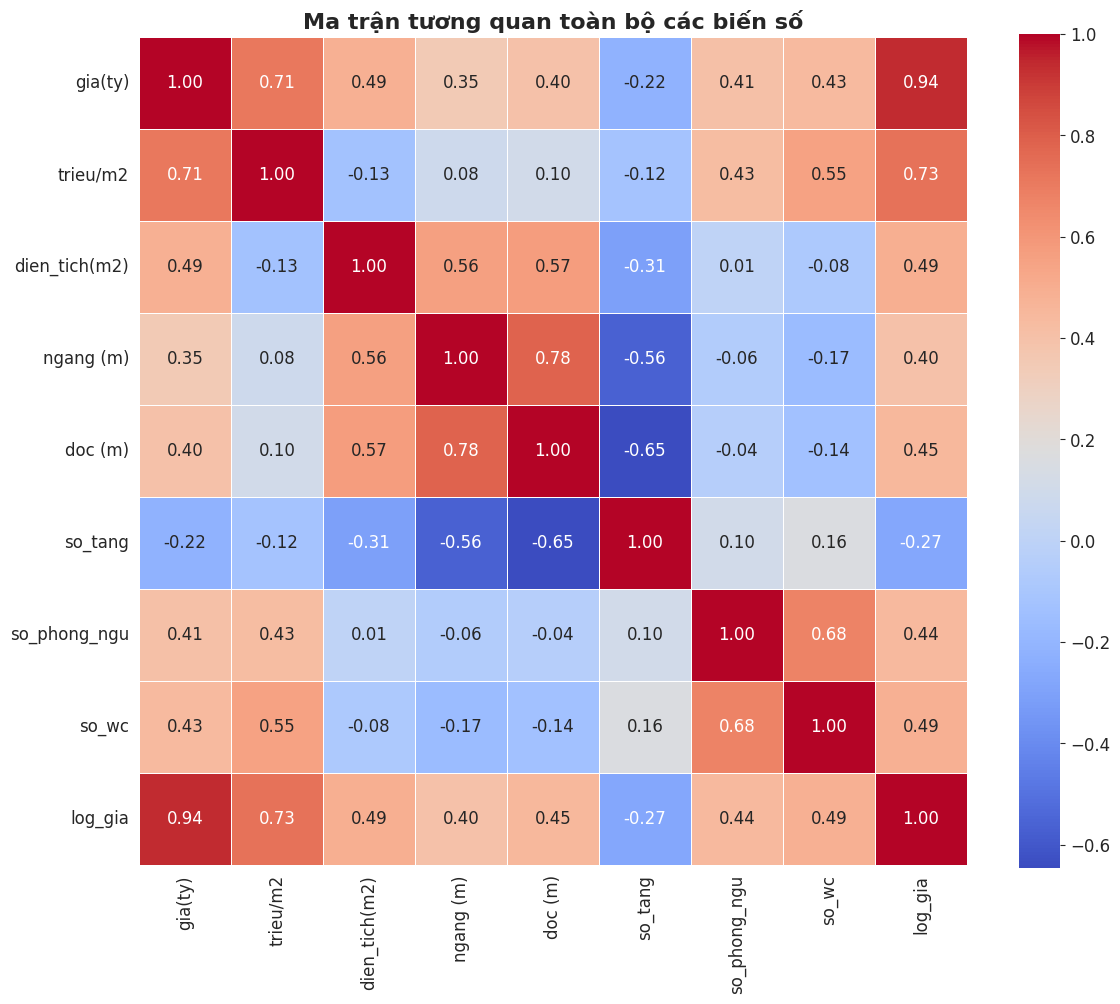

In [44]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    square=True
)
plt.title('Ma trận tương quan toàn bộ các biến số', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Các yếu tố tác động mạnh nhất đến "Giá (tỷ)"

Giá trị trên m2 (trieu/m2): Có tương quan thuận mạnh nhất với tổng giá (gia(ty)) với hệ số 0.71. Điều này khẳng định đơn giá trên diện tích là biến số quan trọng nhất quyết định tổng giá trị bất động sản.

Diện tích (dien_tich(m2)): Có tương quan thuận ở mức trung bình (0.49), cho thấy diện tích lớn hơn đóng góp đáng kể vào tổng giá trị.

Tiện ích nội tại (so_phong_ngu, so_wc): Có tương quan thuận lần lượt là 0.41 và 0.43. Các bất động sản có quy mô lớn hơn về công năng thường có giá trị tổng cao hơn.

Các tương quan đặc thù cần lưu ý

Mối quan hệ giữa kích thước lô đất: Chiều ngang (ngang) và chiều dọc (doc) có tương quan thuận cực kỳ mạnh (0.78), cho thấy các bất động sản có kích thước mặt tiền lớn thường đi kèm với chiều sâu tương ứng, tạo nên những lô đất có quy mô lớn.

Số tầng đối lập với kích thước đất: Đáng chú ý, so_tang có tương quan nghịch khá mạnh với chiều ngang (-0.56) và chiều dọc (-0.65). Điều này gợi ý rằng những ngôi nhà trên diện tích đất lớn thường có xu hướng xây thấp tầng hơn, trong khi những ngôi nhà cao tầng thường được xây trên diện tích đất nhỏ hơn (nhà phố hẹp).

Công năng nội tại: so_phong_ngu và so_wc có tương quan thuận rất cao (0.68), phản ánh cấu trúc thiết kế nhà ở tiêu chuẩn: càng nhiều phòng ngủ thì số lượng nhà vệ sinh thường được thiết kế tăng tương ứng để đảm bảo tiện nghi.

Kết luận chiến lược

"Ma trận tương quan cho thấy thị trường được định hướng mạnh bởi Đơn giá/m2 và Quy mô công năng.

Sự tương quan nghịch giữa số tầng và diện tích đất cho thấy sự phân hóa rõ rệt trong thiết kế: phân khúc nhà phố cao tầng trên đất nhỏ so với biệt thự/nhà sân vườn thấp tầng trên diện tích đất lớn.

Đối với mô hình dự báo giá, các biến trieu/m2, dien_tich và so_wc là những biến số có trọng số cao nhất cần ưu tiên sử dụng."